# Covered Call Strategy — Backtesting Analysis
**Underlying:** S&P 500 Index level (^GSPC)  
**Period:** January 2019 – April 2026  
**Data:** Historical debiased option quotes loaded from parquet  
**Strategy:** Monthly covered calls, short ~30-delta OTM calls, rolled at expiry

---
### Strategy Overview
A **Covered Call** consists of:
- **Long 100 units** of the model underlying exposure (^GSPC)
- **Short 1 OTM call option** per 100 units, typically 30–45 DTE

Premium collected reduces cost basis and generates income, but caps upside above the strike price.

---

## 1. Setup & Dependencies

In [132]:
# Install required packages (run once)
# !pip install yfinance pandas numpy matplotlib seaborn scipy tabulate --quiet

In [133]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
from datetime import datetime, timedelta
from pathlib import Path
from tabulate import tabulate
import math

# --- Style ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
COLORS = {
    'primary':   '#2196F3',
    'secondary': '#FF9800',
    'success':   '#4CAF50',
    'danger':    '#F44336',
    'purple':    '#9C27B0',
    'gray':      '#9E9E9E',
}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Configuration

In [134]:
# ─────────────────────────────────────────────
#  BACKTEST CONFIGURATION — modify as needed
# ─────────────────────────────────────────────
CONFIG = {
    'ticker':           '^GSPC',
    'start_date':       '2019-01-01',
    'end_date':         '2026-04-30',
    'initial_capital':  500_000,      # USD, enough to carry one index-sized covered-call lot
    'shares_per_lot':   100,          # Standard options contract = 100 shares

    # Option parameters
    'target_delta':     0.30,         # Target short call delta (~30-delta = ~1 std OTM)
    'dte_target':       30,           # Days-to-expiry at entry
    'dte_close':        5,            # Close/roll when DTE <= this (0 = hold to expiry)
    'risk_free_rate':   0.04,         # Used for performance statistics only in parquet-backed mode

    # Historical option chain input
    'historical_chain_path':  'option_chain_data/sp500_option_chain_final_debiased.parquet',

    # Cost assumptions
    'commission_per_contract': 0.65,  # USD per options contract
    'commission_per_share':    0.005, # USD per share for equity leg
    'slippage_pct':            0.001, # 0.1% slippage on options premium
}

print('📋 Configuration:')
for k, v in CONFIG.items():
    print(f'   {k:30s}: {v}')

📋 Configuration:
   ticker                        : ^GSPC
   start_date                    : 2019-01-01
   end_date                      : 2026-04-30
   initial_capital               : 500000
   shares_per_lot                : 100
   target_delta                  : 0.3
   dte_target                    : 30
   dte_close                     : 5
   risk_free_rate                : 0.04
   historical_chain_path         : option_chain_data/sp500_option_chain_final_debiased.parquet
   commission_per_contract       : 0.65
   commission_per_share          : 0.005
   slippage_pct                  : 0.001


## 3. Download Market Data

In [135]:
ticker = CONFIG['ticker']

# Download price data with extra buffer for rolling
raw = yf.download(
    ticker,
    start=CONFIG['start_date'],
    end=CONFIG['end_date'],
    auto_adjust=True,
    progress=False
)

# Flatten multi-level columns if needed
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

price_data = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
price_data.index = pd.to_datetime(price_data.index)
price_data = price_data.dropna()

# Compute realised volatility and regime features
price_data['log_ret'] = np.log(price_data['Close'] / price_data['Close'].shift(1))
price_data['rv_21d'] = price_data['log_ret'].rolling(21).std() * np.sqrt(252)
price_data['rv_63d'] = price_data['log_ret'].rolling(63).std() * np.sqrt(252)
price_data['trend_63d'] = price_data['Close'] / price_data['Close'].rolling(63).mean() - 1
price_data['jump_score'] = price_data['log_ret'].abs().rolling(21).max()

# Download VIX as an IV anchor
vix_raw = yf.download(
    '^VIX',
    start=CONFIG['start_date'],
    end=CONFIG['end_date'],
    auto_adjust=True,
    progress=False
)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
price_data['vix'] = vix_raw['Close'].reindex(price_data.index, method='ffill') / 100

# Optional anchor settings retained for descriptive analytics even in parquet-backed mode
iv_assumed = CONFIG.get('iv_assumed', 0.18)
iv_blend_weight = CONFIG.get('iv_blend_weight', 0.75)
iv_floor = CONFIG.get('iv_floor', 0.08)
iv_cap = CONFIG.get('iv_cap', 0.80)

# Blend implied and realised vol into a regime-aware 30D anchor
vol_anchor = price_data['vix'].fillna(iv_assumed)
realised_anchor = price_data['rv_21d'].fillna(price_data['rv_63d']).fillna(iv_assumed)
price_data['iv_base_30d'] = (
    iv_blend_weight * vol_anchor +
    (1 - iv_blend_weight) * realised_anchor
).clip(iv_floor, iv_cap)

stress_score = (
    0.55 * (price_data['rv_21d'] / price_data['rv_63d']).replace([np.inf, -np.inf], np.nan).fillna(1.0) +
    0.30 * (price_data['vix'] / price_data['iv_base_30d']).replace([np.inf, -np.inf], np.nan).fillna(1.0) +
    0.15 * (price_data['jump_score'] / price_data['jump_score'].rolling(63).median()).replace([np.inf, -np.inf], np.nan).fillna(1.0)
)
price_data['stress_score'] = stress_score.clip(lower=0.5, upper=2.0)
price_data['regime_weight'] = ((price_data['stress_score'] - 0.8) / 0.8).clip(lower=0.0, upper=1.0)

print(f'✅ Downloaded {len(price_data)} trading days for {ticker}')
print(f'   Range  : {price_data.index[0].date()} → {price_data.index[-1].date()}')
print(f'   Price  : ${price_data["Close"].iloc[0]:.2f} → ${price_data["Close"].iloc[-1]:.2f}')
print(f'   IV base: {price_data["iv_base_30d"].iloc[-1]:.2%} | Regime weight: {price_data["regime_weight"].iloc[-1]:.2f}')
price_data.tail()

✅ Downloaded 1841 trading days for ^GSPC
   Range  : 2019-01-02 → 2026-04-29
   Price  : $2510.03 → $7135.95
   IV base: 17.66% | Regime weight: 0.30


Price,Open,High,Low,Close,Volume,log_ret,rv_21d,rv_63d,trend_63d,jump_score,vix,iv_base_30d,stress_score,regime_weight
Date,,,,,,,,,,,,,,
2026-04-23,7118.799805,7147.779785,7046.549805,7108.399902,5307260000,-0.004141,0.177500,0.150281,0.042956,0.028715,0.1931,0.189200,1.162459,0.453074
2026-04-24,7136.479980,7168.589844,7112.819824,7165.080078,4608830000,0.007942,0.177997,0.151027,0.050662,0.028715,0.1871,0.184824,1.158569,0.448212
2026-04-27,7152.720215,7178.740234,7146.720215,7173.910156,4783750000,0.001232,0.160391,0.150765,0.051409,0.028715,0.1802,0.175248,1.100248,0.375309
2026-04-28,7133.740234,7152.520020,7115.169922,7138.799805,4900650000,-0.004906,0.144546,0.150971,0.045874,0.028715,0.1783,0.169862,1.048156,0.310195
2026-04-29,7131.609863,7145.629883,7107.859863,7135.950195,5123100000,-0.000399,0.142142,0.150976,0.045073,0.028715,0.1881,0.176611,1.043993,0.304991


In [136]:
def load_historical_option_chain(config, price_data):
    option_path = Path(config['historical_chain_path'])
    if not option_path.is_absolute():
        option_path = Path.cwd() / option_path

    if not option_path.exists():
        raise FileNotFoundError(f'Historical option chain not found: {option_path}')

    use_cols = [
        'date', 'expiry', 'spot', 'strike', 'option_type', 'tenor_days',
        'iv', 'mid', 'bid', 'ask', 'delta', 'gamma', 'theta', 'vega', 'rf_annual'
    ]
    chain = pd.read_parquet(option_path, columns=use_cols).copy()
    chain['date'] = pd.to_datetime(chain['date']).dt.normalize()
    chain['expiry'] = pd.to_datetime(chain['expiry']).dt.normalize()
    chain = chain[chain['option_type'] == 'C'].copy()
    chain['dte_days'] = (chain['expiry'] - chain['date']).dt.days.astype(int)
    chain = chain[chain['dte_days'] > 0].sort_values(['date', 'expiry', 'strike']).reset_index(drop=True)

    chain_dates = pd.DatetimeIndex(chain['date'].unique()).sort_values()
    overlap = price_data.index.intersection(chain_dates)
    if overlap.empty:
        raise ValueError('No overlapping dates between price data and the historical option chain.')

    aligned_price_data = price_data.loc[overlap].copy()
    chain_spot = chain.groupby('date')['spot'].median().reindex(overlap)
    scale = (chain_spot / aligned_price_data['Close']).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    for col in ['Open', 'High', 'Low', 'Close']:
        aligned_price_data[col] = aligned_price_data[col] * scale
    aligned_price_data['chain_spot'] = chain_spot.values

    return aligned_price_data, chain, option_path


price_data, historical_option_chain, historical_chain_path = load_historical_option_chain(CONFIG, price_data)
print(f'✅ Historical option chain loaded: {historical_chain_path}')
print(f'   Call rows       : {len(historical_option_chain):,}')
print(f'   Backtest range  : {price_data.index[0].date()} → {price_data.index[-1].date()}')
print(f'   Median spot     : {historical_option_chain["spot"].median():.2f}')
chain_preview = historical_option_chain.loc[
    historical_option_chain['date'] == historical_option_chain['date'].min(),
    ['date', 'expiry', 'dte_days', 'spot', 'strike', 'iv', 'mid', 'delta']
].head(8)
print(chain_preview.to_string(index=False))

✅ Historical option chain loaded: c:\Users\massi\Documents\PythonAnalytics\option_chain_data\sp500_option_chain_final_debiased.parquet
   Call rows       : 302,742
   Backtest range  : 2021-04-30 → 2026-04-29
   Median spot     : 4677.03
      date     expiry  dte_days        spot  strike       iv     mid    delta
2021-04-30 2021-05-07         7 4181.169922  2803.0 0.385863 1376.97 0.999712
2021-04-30 2021-05-07         7 4181.169922  3097.0 0.347022 1082.97 0.999712
2021-04-30 2021-05-07         7 4181.169922  3256.0 0.325982  923.97 0.999712
2021-04-30 2021-05-07         7 4181.169922  3423.0 0.305819  756.97 0.999711
2021-04-30 2021-05-07         7 4181.169922  3599.0 0.286657  580.97 0.999637
2021-04-30 2021-05-07         7 4181.169922  3708.0 0.275449  472.00 0.998924
2021-04-30 2021-05-07         7 4181.169922  3783.0 0.267250  397.13 0.996397
2021-04-30 2021-05-07         7 4181.169922  3860.0 0.261329  320.68 0.986460


## 4. Historical Option-Chain Utilities

In [137]:
def select_historical_call_snapshot(historical_chain, chain_date=None, dte_choices=(30, 45), target_delta=0.30):
    chain_date = pd.Timestamp(chain_date).normalize() if chain_date is not None else pd.Timestamp(historical_chain['date'].max()).normalize()
    snapshot = historical_chain[historical_chain['date'] == chain_date].copy()
    if snapshot.empty:
        raise ValueError(f'No historical option quotes available for {chain_date.date()}')

    snapshot['dte_gap'] = snapshot['dte_days'].apply(lambda value: min(abs(value - target) for target in dte_choices))
    snapshot['delta_gap'] = (snapshot['delta'].abs() - target_delta).abs()
    return snapshot.sort_values(['dte_gap', 'dte_days', 'delta_gap', 'strike']).reset_index(drop=True)


print('✅ Historical option-chain utilities ready')

# Quick sanity check
latest_chain_date = pd.Timestamp(historical_option_chain['date'].max()).normalize()
sample_chain = select_historical_call_snapshot(
    historical_option_chain,
    chain_date=latest_chain_date,
    dte_choices=(30, 45),
    target_delta=CONFIG['target_delta']
).head(8)
print(f'   Sample date: {latest_chain_date.date()}')
print(f'   Snapshot rows shown: {len(sample_chain):,}')
print(sample_chain[['expiry', 'dte_days', 'strike', 'iv', 'mid', 'bid', 'ask', 'delta']].to_string(index=False))

✅ Historical option-chain utilities ready
   Sample date: 2026-04-29
   Snapshot rows shown: 8
    expiry  dte_days  strike       iv    mid    bid    ask    delta
2026-05-29        30  7427.0 0.223804  79.08  78.95  79.21 0.285957
2026-05-29        30  7280.0 0.229541 130.33 130.12 130.54 0.402852
2026-05-29        30  7577.0 0.220108  44.55  44.48  44.62 0.186072
2026-05-29        30  7730.0 0.217869  23.28  23.24  23.32 0.110815
2026-05-29        30  7136.0 0.234915 197.45 197.12 197.77 0.522909
2026-05-29        30  7886.0 0.215085  10.90  10.88  10.93 0.059057
2026-05-29        30  8046.0 0.213176   4.65   4.62   4.67 0.028335
2026-05-29        30  8291.0 0.211866   1.12   1.09   1.14 0.007938


In [138]:
chain_date = pd.Timestamp(historical_option_chain['date'].max()).normalize()
historical_chain_snapshot = select_historical_call_snapshot(
    historical_option_chain,
    chain_date=chain_date,
    dte_choices=(30, 45),
    target_delta=CONFIG['target_delta']
 )

chain_preview = historical_chain_snapshot.head(12).copy()

print(f'✅ Historical chain snapshot loaded for {chain_date.date()} with {len(historical_chain_snapshot):,} candidate rows')
chain_preview[['expiry', 'dte_days', 'strike', 'iv', 'mid', 'bid', 'ask', 'delta']].reset_index(drop=True)

✅ Historical chain snapshot loaded for 2026-04-29 with 242 candidate rows


,expiry,dte_days,strike,iv,mid,bid,ask,delta
0,2026-05-29,30,7427.0,0.223804,79.08,78.95,79.21,0.285957
1,2026-05-29,30,7280.0,0.229541,130.33,130.12,130.54,0.402852
2,2026-05-29,30,7577.0,0.220108,44.55,44.48,44.62,0.186072
3,2026-05-29,30,7730.0,0.217869,23.28,23.24,23.32,0.110815
4,2026-05-29,30,7136.0,0.234915,197.45,197.12,197.77,0.522909
5,2026-05-29,30,7886.0,0.215085,10.90,10.88,10.93,0.059057
6,2026-05-29,30,8046.0,0.213176,4.65,4.62,4.67,0.028335
7,2026-05-29,30,8291.0,0.211866,1.12,1.09,1.14,0.007938
8,2026-05-29,30,8716.0,0.210991,0.07,0.04,0.09,0.000580
9,2026-05-29,30,9163.0,0.212652,0.00,0.00,0.05,0.000026


## 5. Covered Call Backtesting Engine

In [139]:
def run_covered_call_backtest(price_data, config, historical_chain):
    """Simulate a covered call strategy using only the saved historical option chain."""
    shares_per_lot = config['shares_per_lot']
    initial_capital = config['initial_capital']
    commission_per_contract = config['commission_per_contract']
    commission_per_share = config['commission_per_share']
    dte_target = config['dte_target']
    dte_close_threshold = config['dte_close']
    target_delta = config['target_delta']
    assignment_fee = config.get('assignment_fee', 0.0)

    if historical_chain is None or historical_chain.empty:
        raise ValueError('Historical option chain is required for the backtest.')

    trading_index = price_data.index
    historical_chain = historical_chain.copy()
    historical_chain['date'] = pd.to_datetime(historical_chain['date']).dt.normalize()
    historical_chain['expiry'] = pd.to_datetime(historical_chain['expiry']).dt.normalize()
    historical_chain_by_date = {
        dt: grp.reset_index(drop=True)
        for dt, grp in historical_chain.groupby('date', sort=True)
    }

    def next_trading_day(current_date):
        position = trading_index.searchsorted(current_date, side='right')
        if position >= len(trading_index):
            return None
        return trading_index[position]

    def prior_trading_day(target_date):
        position = trading_index.searchsorted(target_date, side='right') - 1
        if position < 0:
            return None
        return trading_index[position]

    def get_daily_calls(chain_date):
        return historical_chain_by_date.get(pd.Timestamp(chain_date).normalize())

    def select_expiry(signal_date):
        daily_chain = get_daily_calls(signal_date)
        if daily_chain is None or daily_chain.empty:
            return None, None

        expiries = daily_chain[['expiry', 'dte_days']].drop_duplicates().sort_values('dte_days').reset_index(drop=True)
        eligible = expiries[expiries['dte_days'] >= dte_target]
        chosen = eligible.iloc[0] if not eligible.empty else expiries.iloc[-1]
        formal_expiry = pd.Timestamp(chosen['expiry']).normalize()
        expiry_session = prior_trading_day(formal_expiry)
        if expiry_session is None:
            return None, None
        return formal_expiry, expiry_session.normalize()

    def quote_from_chain(chain_date, strike, formal_expiry):
        target_dte = max(int((pd.Timestamp(formal_expiry).normalize() - pd.Timestamp(chain_date).normalize()).days), 1)
        daily_chain = get_daily_calls(chain_date)
        if daily_chain is None or daily_chain.empty:
            raise ValueError(f'No option quotes available for {pd.Timestamp(chain_date).date()}')

        candidates = daily_chain.copy()
        candidates['expiry_diff'] = (candidates['dte_days'] - target_dte).abs()
        candidates['strike_diff'] = (candidates['strike'] - strike).abs()
        selected = candidates.sort_values(['expiry_diff', 'strike_diff', 'strike']).iloc[0]
        return {
            'date': pd.Timestamp(chain_date),
            'expiry': pd.Timestamp(selected['expiry']),
            'dte_days': int(selected['dte_days']),
            'strike': float(selected['strike']),
            'spot': float(selected['spot']),
            'iv': float(selected['iv']),
            'call_mid': float(selected['mid']),
            'call_bid': float(selected['bid']),
            'call_ask': float(selected['ask']),
            'call_delta': float(selected['delta']),
            'call_gamma': float(selected['gamma']),
            'call_theta': float(selected['theta']),
            'call_vega': float(selected['vega']),
        }

    def apply_option_fill(quote, side):
        return float(quote['call_bid'] if side == 'sell' else quote['call_ask'])

    def build_pending_open(signal_date, spot_close):
        execute_date = next_trading_day(signal_date)
        if execute_date is None:
            return None
        formal_expiry, expiry_session = select_expiry(signal_date)
        if formal_expiry is None or expiry_session is None:
            return None

        daily_chain = get_daily_calls(signal_date)
        if daily_chain is None or daily_chain.empty:
            return None

        candidates = daily_chain.copy()
        candidates['expiry_diff'] = (candidates['dte_days'] - dte_target).abs()
        candidates['delta_diff'] = (candidates['delta'].abs() - target_delta).abs()
        candidates['otm_penalty'] = (candidates['strike'] < spot_close).astype(int)
        chosen = candidates.sort_values(['expiry_diff', 'otm_penalty', 'delta_diff', 'strike']).iloc[0]
        formal_expiry = pd.Timestamp(chosen['expiry']).normalize()
        expiry_session = prior_trading_day(formal_expiry)
        if expiry_session is None or expiry_session < execute_date:
            return None

        return {
            'execute_date': execute_date,
            'signal_date': signal_date,
            'formal_expiry': formal_expiry,
            'expiry_session': expiry_session.normalize(),
            'strike': float(chosen['strike']),
            'signal_iv': float(chosen['iv']),
            'signal_delta': float(chosen['delta']),
            'signal_dte': int(chosen['dte_days']),
        }

    def record_trade(position, close_date, close_price, pnl, assigned, close_reason, close_underlying):
        trades.append({
            'entry_date': position['entry_date'],
            'close_date': close_date,
            'expiry_date': position['formal_expiry'],
            'close_reason': close_reason,
            'strike': position['strike'],
            'entry_price': position['entry_price'],
            'close_price': close_price,
            'lots': position['lots'],
            'premium_collected': position['entry_price'] * shares_per_lot * position['lots'],
            'pnl': pnl,
            'S_at_entry': position['S_entry'],
            'S_at_close': close_underlying,
            'iv_at_entry': position['iv_entry'],
            'assigned': assigned,
            'entry_delta': position['entry_delta'],
        })

    first_open = float(price_data['Open'].iloc[0])
    deployable_cash = initial_capital * 0.95
    num_lots = int(deployable_cash // (first_open * shares_per_lot))
    if num_lots <= 0:
        raise ValueError('Initial capital is insufficient to purchase one covered-call lot.')

    total_shares = num_lots * shares_per_lot
    cash = initial_capital - (total_shares * first_open) - (total_shares * commission_per_share)

    trades = []
    portfolio_ts = []
    open_call = None
    pending_open = build_pending_open(trading_index[0], float(price_data['Close'].iloc[0]))
    pending_close = None
    pending_rebuy_lots = 0

    for date, row in price_data.iterrows():
        open_price = float(row['Open'])
        close_price = float(row['Close'])

        if pending_rebuy_lots > 0 and total_shares == 0:
            rebuy_shares = pending_rebuy_lots * shares_per_lot
            rebuy_cost = rebuy_shares * open_price + rebuy_shares * commission_per_share
            if rebuy_cost <= cash:
                cash -= rebuy_cost
                total_shares += rebuy_shares
            pending_rebuy_lots = 0

        if open_call is not None and pending_close is not None and pending_close['execute_date'] == date:
            close_quote = quote_from_chain(date, open_call['strike'], open_call['formal_expiry'])
            close_fill = apply_option_fill(close_quote, 'buy')
            close_commission = commission_per_contract * open_call['lots']
            pnl = (open_call['entry_price'] - close_fill) * shares_per_lot * open_call['lots'] - close_commission
            cash += pnl
            record_trade(open_call, date, close_fill, pnl, False, 'roll', open_price)
            open_call = None
            pending_close = None

        if pending_open is not None and pending_open['execute_date'] == date and total_shares >= shares_per_lot and open_call is None:
            lots = total_shares // shares_per_lot
            entry_quote = quote_from_chain(date, pending_open['strike'], pending_open['formal_expiry'])
            entry_fill = apply_option_fill(entry_quote, 'sell')
            cash += entry_fill * shares_per_lot * lots - commission_per_contract * lots
            open_call = {
                'entry_date': date,
                'signal_date': pending_open['signal_date'],
                'formal_expiry': pending_open['formal_expiry'],
                'expiry_session': pending_open['expiry_session'],
                'strike': pending_open['strike'],
                'entry_price': entry_fill,
                'current_price': entry_quote['call_mid'],
                'lots': lots,
                'S_entry': open_price,
                'iv_entry': entry_quote['iv'],
                'entry_delta': entry_quote['call_delta'],
                'dte': entry_quote['dte_days'],
            }
            pending_open = None

        short_call_value = 0.0
        delta_port = total_shares
        gamma_port = 0.0
        theta_port = 0.0
        vega_port = 0.0
        current_option_iv = np.nan

        if open_call is not None:
            mtm_quote = quote_from_chain(date, open_call['strike'], open_call['formal_expiry'])
            current_mid = mtm_quote['call_mid']
            current_option_iv = mtm_quote['iv']
            open_call['current_price'] = current_mid
            open_call['dte'] = mtm_quote['dte_days']
            short_call_value = -current_mid * shares_per_lot * open_call['lots']
            delta_port -= mtm_quote['call_delta'] * shares_per_lot * open_call['lots']
            gamma_port -= mtm_quote['call_gamma'] * shares_per_lot * open_call['lots']
            theta_port -= mtm_quote['call_theta'] * shares_per_lot * open_call['lots']
            vega_port -= mtm_quote['call_vega'] * shares_per_lot * open_call['lots']

        equity_value = total_shares * close_price
        portfolio_value = cash + equity_value + short_call_value

        portfolio_ts.append({
            'date': date,
            'S': close_price,
            'iv': current_option_iv,
            'portfolio_value': portfolio_value,
            'equity_value': equity_value,
            'cash': cash,
            'short_calls_mtm': short_call_value,
            'delta': delta_port,
            'gamma': gamma_port,
            'theta': theta_port,
            'vega': vega_port,
        })

        if open_call is not None:
            next_date = next_trading_day(date)
            should_roll = open_call['dte'] <= dte_close_threshold and date < open_call['expiry_session']
            expires_today = date >= open_call['expiry_session']

            if expires_today:
                intrinsic_value = max(close_price - open_call['strike'], 0)
                option_pnl = (open_call['entry_price'] - intrinsic_value) * shares_per_lot * open_call['lots']
                assigned = close_price >= open_call['strike']
                if assigned:
                    assignment_shares = open_call['lots'] * shares_per_lot
                    cash += open_call['strike'] * assignment_shares - assignment_fee
                    total_shares -= assignment_shares
                    pending_rebuy_lots = open_call['lots']
                record_trade(open_call, date, intrinsic_value, option_pnl, assigned, 'expiry', close_price)
                next_signal = build_pending_open(date, close_price) if next_date is not None else None
                if assigned and next_signal is not None:
                    pending_open = next_signal
                elif total_shares >= shares_per_lot and next_signal is not None:
                    pending_open = next_signal
                open_call = None
                pending_close = None
            elif should_roll and next_date is not None:
                pending_close = {'execute_date': next_date}
                pending_open = build_pending_open(date, close_price)
        elif pending_open is None and total_shares >= shares_per_lot:
            next_signal = build_pending_open(date, close_price)
            if next_signal is not None:
                pending_open = next_signal

    port_df = pd.DataFrame(portfolio_ts).set_index('date')
    trades_df = pd.DataFrame(trades)
    return port_df, trades_df


print('✅ Historical-chain backtest engine defined')

✅ Historical-chain backtest engine defined


## 6. Run the Backtest

In [140]:
data_source = 'historical debiased option chain parquet'
print(f'🚀 Running Covered Call backtest on {CONFIG["ticker"]} ({price_data.index[0].date()} → {price_data.index[-1].date()}) using {data_source}...')

port_df, trades_df = run_covered_call_backtest(price_data, CONFIG, historical_chain=historical_option_chain)

# ── Build buy-and-hold benchmark ────────────────────────────────────────────
bh_shares = CONFIG['initial_capital'] // price_data['Close'].iloc[0]
bh_df = pd.DataFrame(index=price_data.index)
bh_df['portfolio_value'] = bh_shares * price_data['Close']

print(f'✅ Backtest complete')
print(f'   Total trades  : {len(trades_df)}')
print(f'   Trading days  : {len(port_df)}')
print(f'   Start value   : ${port_df["portfolio_value"].iloc[0]:>12,.2f}')
print(f'   End value     : ${port_df["portfolio_value"].iloc[-1]:>12,.2f}')
print(f'   B&H end value : ${bh_df["portfolio_value"].iloc[-1]:>12,.2f}')

🚀 Running Covered Call backtest on ^GSPC (2021-04-30 → 2026-04-29) using historical debiased option chain parquet...
✅ Backtest complete
   Total trades  : 66
   Trading days  : 1251
   Start value   : $  498,306.48
   End value     : $1,059,032.07
   B&H end value : $  849,178.07


## 7. Risk & Performance Metrics

In [141]:
def compute_metrics(portfolio_values, initial_capital, trades_df=None, label='Strategy'):
    pv   = portfolio_values.dropna()
    rets = pv.pct_change().dropna()
    n    = len(rets)

    total_return   = (pv.iloc[-1] / pv.iloc[0]) - 1
    years          = n / 252
    cagr           = (pv.iloc[-1] / pv.iloc[0]) ** (1 / years) - 1

    ann_vol        = rets.std() * np.sqrt(252)
    sharpe         = (rets.mean() * 252 - CONFIG['risk_free_rate']) / ann_vol if ann_vol > 0 else 0

    # Sortino (downside vol)
    neg_rets       = rets[rets < 0]
    downside_vol   = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 0 else 1e-9
    sortino        = (rets.mean() * 252 - CONFIG['risk_free_rate']) / downside_vol

    # Max drawdown
    roll_max       = pv.cummax()
    drawdown       = (pv - roll_max) / roll_max
    max_dd         = drawdown.min()

    # Calmar
    calmar         = cagr / abs(max_dd) if max_dd != 0 else 0

    # VaR & CVaR (95% and 99%)
    var_95         = np.percentile(rets, 5)
    cvar_95        = rets[rets <= var_95].mean()
    var_99         = np.percentile(rets, 1)
    cvar_99        = rets[rets <= var_99].mean()

    # Omega ratio (threshold = 0)
    gains          = rets[rets > 0].sum()
    losses         = abs(rets[rets < 0].sum())
    omega          = gains / losses if losses > 0 else np.inf

    # Hit rate / best / worst day
    hit_rate       = (rets > 0).mean()
    best_day       = rets.max()
    worst_day      = rets.min()

    # Drawdown duration
    underwater     = drawdown < 0
    dd_runs        = underwater.ne(underwater.shift()).cumsum()
    dd_lens        = drawdown[underwater].groupby(dd_runs[underwater]).size()
    max_dd_dur     = dd_lens.max() if len(dd_lens) > 0 else 0

    metrics = {
        'label':           label,
        'total_return':    total_return,
        'cagr':            cagr,
        'ann_volatility':  ann_vol,
        'sharpe':          sharpe,
        'sortino':         sortino,
        'calmar':          calmar,
        'max_drawdown':    max_dd,
        'max_dd_duration': max_dd_dur,
        'var_95':          var_95,
        'cvar_95':         cvar_95,
        'var_99':          var_99,
        'cvar_99':         cvar_99,
        'omega_ratio':     omega,
        'hit_rate':        hit_rate,
        'best_day':        best_day,
        'worst_day':       worst_day,
        'drawdown_series': drawdown,
    }

    if trades_df is not None and len(trades_df) > 0:
        metrics['n_trades']         = len(trades_df)
        metrics['win_rate']         = (trades_df['pnl'] > 0).mean()
        metrics['avg_pnl']          = trades_df['pnl'].mean()
        metrics['total_premium']    = trades_df['premium_collected'].sum()
        metrics['avg_premium']      = trades_df['premium_collected'].mean()
        metrics['profit_factor']    = (trades_df.loc[trades_df['pnl']>0,'pnl'].sum() /
                                       abs(trades_df.loc[trades_df['pnl']<0,'pnl'].sum() + 1e-9))
        metrics['assign_rate']      = trades_df['assigned'].mean() if 'assigned' in trades_df.columns else 0

    return metrics


strat_metrics = compute_metrics(
    port_df['portfolio_value'], CONFIG['initial_capital'], trades_df, label='Covered Call'
)
bh_metrics = compute_metrics(
    bh_df['portfolio_value'], CONFIG['initial_capital'], label='Buy & Hold'
)

# ── Print comparison table ──────────────────────────────────────────────────
rows = [
    ('Total Return',          f"{strat_metrics['total_return']:.1%}",     f"{bh_metrics['total_return']:.1%}"),
    ('CAGR',                  f"{strat_metrics['cagr']:.1%}",             f"{bh_metrics['cagr']:.1%}"),
    ('Ann. Volatility',       f"{strat_metrics['ann_volatility']:.1%}",   f"{bh_metrics['ann_volatility']:.1%}"),
    ('Sharpe Ratio',          f"{strat_metrics['sharpe']:.3f}",           f"{bh_metrics['sharpe']:.3f}"),
    ('Sortino Ratio',         f"{strat_metrics['sortino']:.3f}",          f"{bh_metrics['sortino']:.3f}"),
    ('Calmar Ratio',          f"{strat_metrics['calmar']:.3f}",           f"{bh_metrics['calmar']:.3f}"),
    ('Max Drawdown',          f"{strat_metrics['max_drawdown']:.1%}",     f"{bh_metrics['max_drawdown']:.1%}"),
    ('Max DD Duration (days)',f"{strat_metrics['max_dd_duration']}",      f"{bh_metrics['max_dd_duration']}"),
    ('VaR 95% (daily)',       f"{strat_metrics['var_95']:.2%}",           f"{bh_metrics['var_95']:.2%}"),
    ('CVaR 95% (daily)',      f"{strat_metrics['cvar_95']:.2%}",          f"{bh_metrics['cvar_95']:.2%}"),
    ('VaR 99% (daily)',       f"{strat_metrics['var_99']:.2%}",           f"{bh_metrics['var_99']:.2%}"),
    ('CVaR 99% (daily)',      f"{strat_metrics['cvar_99']:.2%}",          f"{bh_metrics['cvar_99']:.2%}"),
    ('Omega Ratio',           f"{strat_metrics['omega_ratio']:.3f}",      f"{bh_metrics['omega_ratio']:.3f}"),
    ('Daily Hit Rate',        f"{strat_metrics['hit_rate']:.1%}",         f"{bh_metrics['hit_rate']:.1%}"),
    ('Best Day',              f"{strat_metrics['best_day']:.2%}",         f"{bh_metrics['best_day']:.2%}"),
    ('Worst Day',             f"{strat_metrics['worst_day']:.2%}",        f"{bh_metrics['worst_day']:.2%}"),
]

if 'n_trades' in strat_metrics:
    rows += [
        ('', '', ''),
        ('── Options Stats ──', '', ''),
        ('# Trades',           str(strat_metrics['n_trades']),            '—'),
        ('Win Rate (trades)',  f"{strat_metrics['win_rate']:.1%}",        '—'),
        ('Profit Factor',      f"{strat_metrics['profit_factor']:.2f}",   '—'),
        ('Avg Premium/Trade',  f"${strat_metrics['avg_premium']:,.2f}",   '—'),
        ('Total Premium',      f"${strat_metrics['total_premium']:,.0f}", '—'),
        ('Assignment Rate',    f"{strat_metrics['assign_rate']:.1%}",     '—'),
    ]

print('\n' + '='*60)
print(f'  BACKTEST RESULTS: {CONFIG["ticker"]} Covered Call vs Buy & Hold')
print('='*60)
print(tabulate(rows, headers=['Metric', 'Covered Call', 'Buy & Hold'], tablefmt='rounded_outline'))


  BACKTEST RESULTS: ^GSPC Covered Call vs Buy & Hold
╭────────────────────────┬────────────────┬──────────────╮
│ Metric                 │ Covered Call   │ Buy & Hold   │
├────────────────────────┼────────────────┼──────────────┤
│ Total Return           │ 112.5%         │ 70.7%        │
│ CAGR                   │ 16.4%          │ 11.4%        │
│ Ann. Volatility        │ 11.0%          │ 17.0%        │
│ Sharpe Ratio           │ 1.077          │ 0.484        │
│ Sortino Ratio          │ 1.435          │ 0.665        │
│ Calmar Ratio           │ 1.211          │ 0.448        │
│ Max Drawdown           │ -13.6%         │ -25.4%       │
│ Max DD Duration (days) │ 358            │ 512          │
│ VaR 95% (daily)        │ -1.07%         │ -1.65%       │
│ CVaR 95% (daily)       │ -1.61%         │ -2.46%       │
│ VaR 99% (daily)        │ -2.08%         │ -2.97%       │
│ CVaR 99% (daily)       │ -2.54%         │ -3.81%       │
│ Omega Ratio            │ 1.290          │ 1.136        │
│ 

## 8. Equity Curve & Drawdown

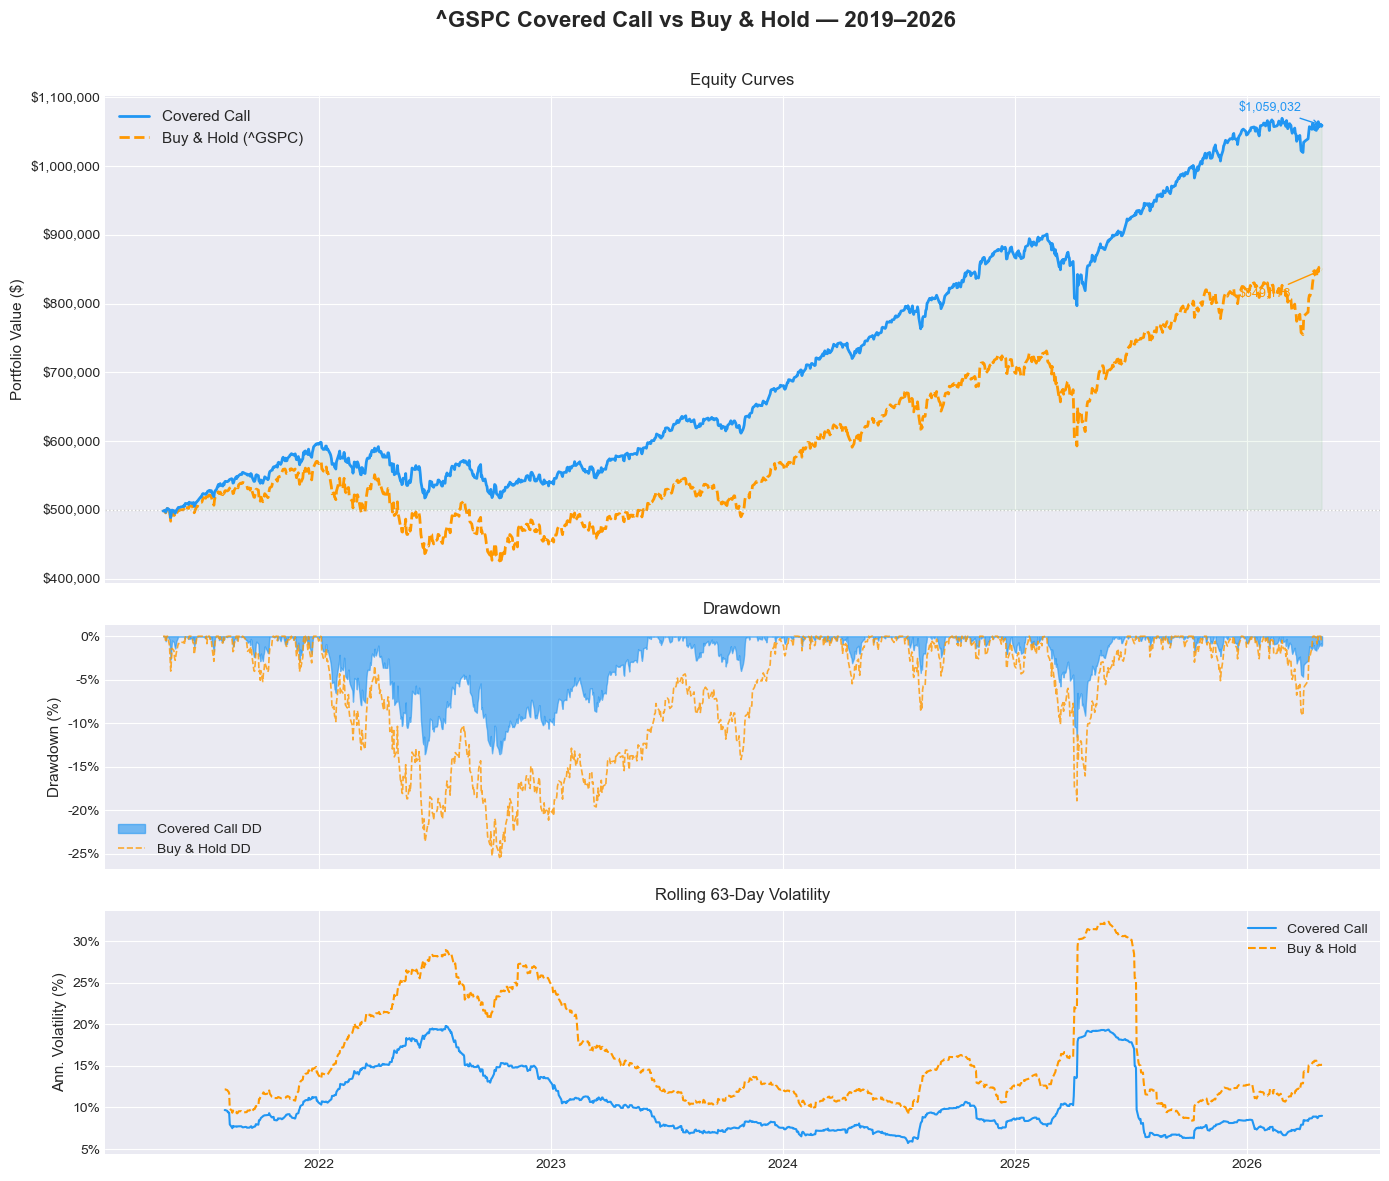

📊 Chart saved to c:\Users\massi\Documents\PythonAnalytics\outputs\01_equity_curve.png


In [142]:
from pathlib import Path

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
fig.suptitle(f'{CONFIG["ticker"]} Covered Call vs Buy & Hold — {CONFIG["start_date"][:4]}–{CONFIG["end_date"][:4]}', fontsize=16, fontweight='bold', y=0.98)

# ── Panel 1: Equity Curves ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(port_df.index, port_df['portfolio_value'],
         color=COLORS['primary'], lw=2, label='Covered Call', zorder=3)
ax1.plot(bh_df.index, bh_df['portfolio_value'],
         color=COLORS['secondary'], lw=2, linestyle='--', label=f'Buy & Hold ({CONFIG["ticker"]})', zorder=2)
ax1.axhline(CONFIG['initial_capital'], color=COLORS['gray'], linestyle=':', lw=1, alpha=0.5)
ax1.fill_between(port_df.index, port_df['portfolio_value'], CONFIG['initial_capital'],
                  where=port_df['portfolio_value'] >= CONFIG['initial_capital'],
                  alpha=0.08, color=COLORS['success'])
ax1.fill_between(port_df.index, port_df['portfolio_value'], CONFIG['initial_capital'],
                  where=port_df['portfolio_value'] < CONFIG['initial_capital'],
                  alpha=0.15, color=COLORS['danger'])
ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=11, loc='upper left')
ax1.set_title('Equity Curves', fontsize=12, pad=8)

# Annotate end values
ax1.annotate(f"${port_df['portfolio_value'].iloc[-1]:,.0f}",
             xy=(port_df.index[-1], port_df['portfolio_value'].iloc[-1]),
             xytext=(-60, 10), textcoords='offset points',
             fontsize=9, color=COLORS['primary'],
             arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=1))
ax1.annotate(f"${bh_df['portfolio_value'].iloc[-1]:,.0f}",
             xy=(bh_df.index[-1], bh_df['portfolio_value'].iloc[-1]),
             xytext=(-60, -20), textcoords='offset points',
             fontsize=9, color=COLORS['secondary'],
             arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=1))

# ── Panel 2: Drawdown ───────────────────────────────────────────────────────
ax2 = axes[1]
dd_strat = strat_metrics['drawdown_series']
dd_bh    = bh_metrics['drawdown_series']
ax2.fill_between(dd_strat.index, dd_strat * 100, 0,
                  alpha=0.6, color=COLORS['primary'], label='Covered Call DD')
ax2.plot(dd_bh.index, dd_bh * 100,
         color=COLORS['secondary'], lw=1.2, linestyle='--', alpha=0.8, label='Buy & Hold DD')
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=10, loc='lower left')
ax2.set_title('Drawdown', fontsize=12, pad=8)

# ── Panel 3: Rolling 63-day Volatility ─────────────────────────────────────
ax3 = axes[2]
strat_rets = port_df['portfolio_value'].pct_change()
bh_rets    = bh_df['portfolio_value'].pct_change()
rv_strat   = strat_rets.rolling(63).std() * np.sqrt(252) * 100
rv_bh      = bh_rets.rolling(63).std()   * np.sqrt(252) * 100
ax3.plot(rv_strat.index, rv_strat, color=COLORS['primary'], lw=1.5, label='Covered Call')
ax3.plot(rv_bh.index,    rv_bh,    color=COLORS['secondary'], lw=1.5, linestyle='--', label='Buy & Hold')
ax3.set_ylabel('Ann. Volatility (%)', fontsize=11)
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.legend(fontsize=10)
ax3.set_title('Rolling 63-Day Volatility', fontsize=12, pad=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

output_dir = Path.cwd() / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)
equity_curve_path = output_dir / '01_equity_curve.png'

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(equity_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Chart saved to {equity_curve_path}')

## 9. Return Distribution Analysis

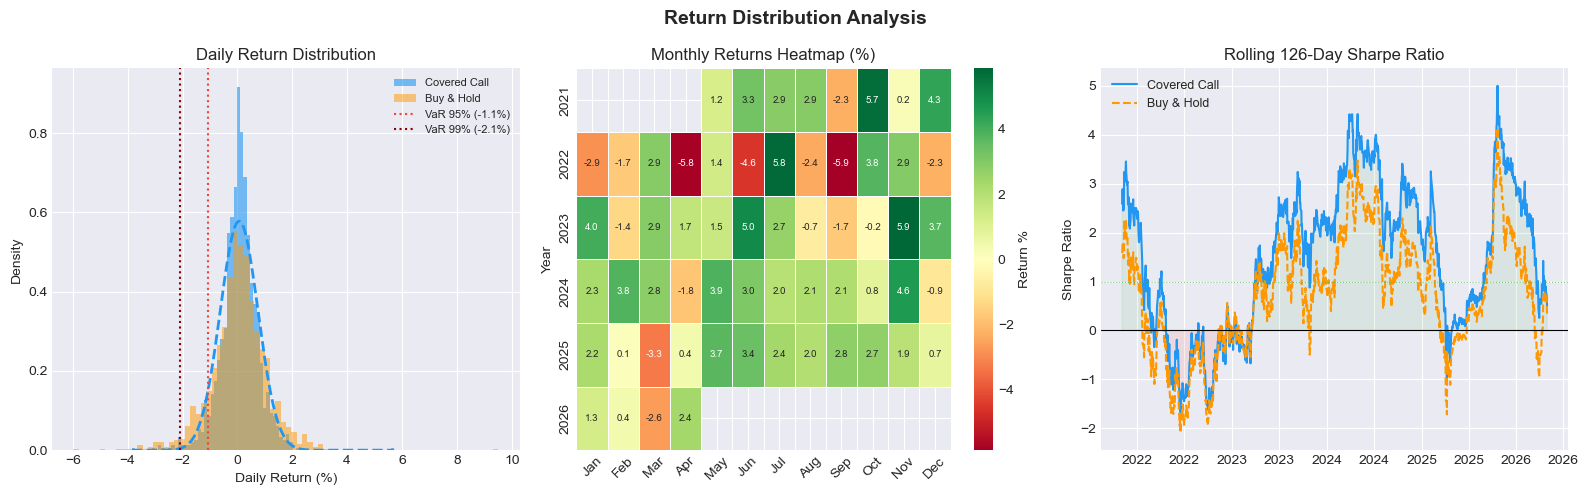

📊 Chart saved


In [143]:
strat_rets = port_df['portfolio_value'].pct_change().dropna()
bh_rets    = bh_df['portfolio_value'].pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Return Distribution Analysis', fontsize=14, fontweight='bold')

# ── Daily Returns Distribution ──────────────────────────────────────────────
ax = axes[0]
ax.hist(strat_rets * 100, bins=80, alpha=0.6, color=COLORS['primary'],
        density=True, label='Covered Call')
ax.hist(bh_rets * 100,    bins=80, alpha=0.5, color=COLORS['secondary'],
        density=True, label='Buy & Hold')
# Normal fit
x = np.linspace(strat_rets.min() * 100, strat_rets.max() * 100, 200)
ax.plot(x, norm.pdf(x, strat_rets.mean()*100, strat_rets.std()*100),
        color=COLORS['primary'], lw=2, linestyle='--')
# VaR lines
ax.axvline(strat_metrics['var_95']*100, color=COLORS['danger'], lw=1.5,
           linestyle=':', label=f'VaR 95% ({strat_metrics["var_95"]*100:.1f}%)')
ax.axvline(strat_metrics['var_99']*100, color='darkred', lw=1.5,
           linestyle=':', label=f'VaR 99% ({strat_metrics["var_99"]*100:.1f}%)')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.set_title('Daily Return Distribution')
ax.legend(fontsize=8)

# ── Monthly Returns Heatmap ─────────────────────────────────────────────────
ax = axes[1]
monthly = port_df['portfolio_value'].resample('ME').last().pct_change().dropna() * 100
monthly_df = pd.DataFrame({'ret': monthly})
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot_table(values='ret', index='year', columns='month', aggfunc='first')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Return %'}, annot_kws={'size': 7})
ax.set_title('Monthly Returns Heatmap (%)')
ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=45)

# ── Rolling Sharpe ──────────────────────────────────────────────────────────
ax = axes[2]
window = 126  # ~6 months
rf_daily = CONFIG['risk_free_rate'] / 252
roll_sharpe_strat = ((strat_rets - rf_daily).rolling(window).mean() /
                     strat_rets.rolling(window).std() * np.sqrt(252))
roll_sharpe_bh    = ((bh_rets - rf_daily).rolling(window).mean() /
                     bh_rets.rolling(window).std() * np.sqrt(252))
ax.plot(roll_sharpe_strat.index, roll_sharpe_strat,
        color=COLORS['primary'], lw=1.5, label='Covered Call')
ax.plot(roll_sharpe_bh.index,    roll_sharpe_bh,
        color=COLORS['secondary'], lw=1.5, linestyle='--', label='Buy & Hold')
ax.axhline(0, color='black', lw=0.8, linestyle='-')
ax.axhline(1, color=COLORS['success'], lw=0.8, linestyle=':', alpha=0.7)
ax.fill_between(roll_sharpe_strat.index, roll_sharpe_strat, 0,
                where=roll_sharpe_strat > 0, alpha=0.1, color=COLORS['success'])
ax.fill_between(roll_sharpe_strat.index, roll_sharpe_strat, 0,
                where=roll_sharpe_strat < 0, alpha=0.1, color=COLORS['danger'])
ax.set_title(f'Rolling {window}-Day Sharpe Ratio')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
output_dir.mkdir(parents=True, exist_ok=True)
return_distribution_path = output_dir / '02_return_distribution.png'
plt.savefig(return_distribution_path, dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved')

## 10. Trade-Level Analysis

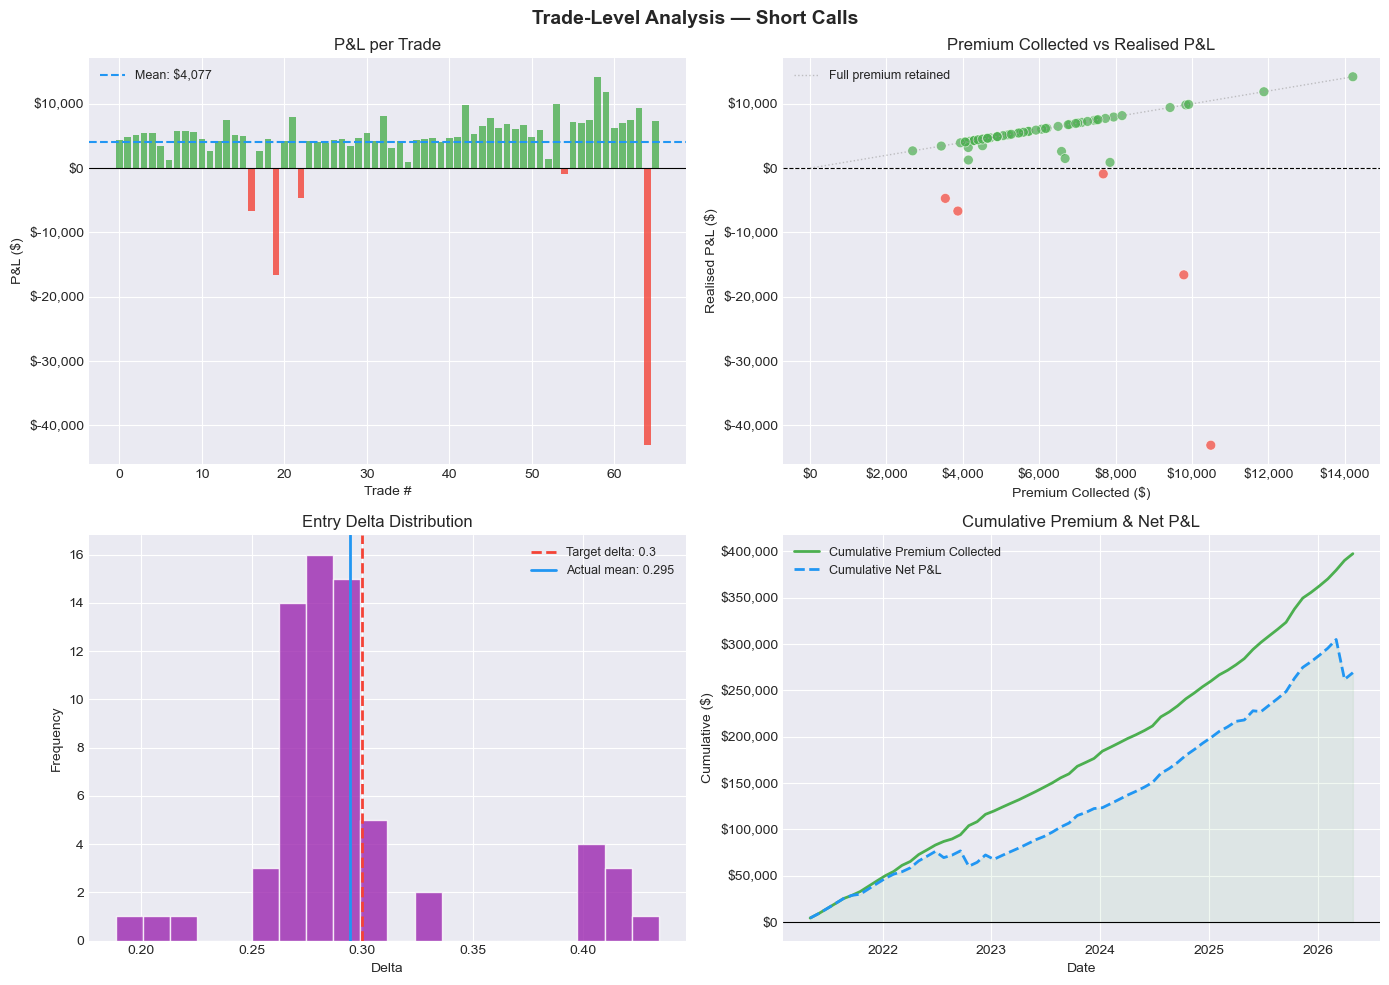

📊 Chart saved to c:\Users\massi\Documents\PythonAnalytics\outputs\03_trade_analysis.png


In [144]:
if len(trades_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Trade-Level Analysis — Short Calls', fontsize=14, fontweight='bold')

    # ── P&L per trade ───────────────────────────────────────────────────────
    ax = axes[0, 0]
    colors = [COLORS['success'] if p > 0 else COLORS['danger'] for p in trades_df['pnl']]
    ax.bar(range(len(trades_df)), trades_df['pnl'], color=colors, alpha=0.8, width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(trades_df['pnl'].mean(), color=COLORS['primary'], lw=1.5,
               linestyle='--', label=f'Mean: ${trades_df["pnl"].mean():,.0f}')
    ax.set_title('P&L per Trade')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)

    # ── Premium collected vs P&L ────────────────────────────────────────────
    ax = axes[0, 1]
    ax.scatter(trades_df['premium_collected'], trades_df['pnl'],
               c=colors, alpha=0.7, s=50, edgecolors='white', lw=0.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    # Diagonal line (full premium kept)
    mx = trades_df['premium_collected'].max()
    ax.plot([0, mx], [0, mx], color=COLORS['gray'], lw=1, linestyle=':', alpha=0.6,
            label='Full premium retained')
    ax.set_title('Premium Collected vs Realised P&L')
    ax.set_xlabel('Premium Collected ($)')
    ax.set_ylabel('Realised P&L ($)')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)

    # ── Entry delta distribution ────────────────────────────────────────────
    ax = axes[1, 0]
    ax.hist(trades_df['entry_delta'], bins=20, color=COLORS['purple'], alpha=0.8, edgecolor='white')
    ax.axvline(CONFIG['target_delta'], color=COLORS['danger'], lw=2,
               linestyle='--', label=f'Target delta: {CONFIG["target_delta"]}')
    ax.axvline(trades_df['entry_delta'].mean(), color=COLORS['primary'], lw=2,
               linestyle='-', label=f'Actual mean: {trades_df["entry_delta"].mean():.3f}')
    ax.set_title('Entry Delta Distribution')
    ax.set_xlabel('Delta')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

    # ── Cumulative premium income ───────────────────────────────────────────
    ax = axes[1, 1]
    cumulative_prem = trades_df.set_index('entry_date')['premium_collected'].cumsum()
    cumulative_pnl  = trades_df.set_index('entry_date')['pnl'].cumsum()
    ax.plot(cumulative_prem.index, cumulative_prem,
            color=COLORS['success'], lw=2, label='Cumulative Premium Collected')
    ax.plot(cumulative_pnl.index, cumulative_pnl,
            color=COLORS['primary'], lw=2, linestyle='--', label='Cumulative Net P&L')
    ax.axhline(0, color='black', lw=0.8)
    ax.fill_between(cumulative_pnl.index, cumulative_pnl, 0,
                    where=cumulative_pnl >= 0, alpha=0.08, color=COLORS['success'])
    ax.set_title('Cumulative Premium & Net P&L')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative ($)')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=9)

    fig.tight_layout()
    output_dir.mkdir(parents=True, exist_ok=True)
    trade_analysis_path = output_dir / '03_trade_analysis.png'
    plt.savefig(trade_analysis_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'📊 Chart saved to {trade_analysis_path}')

## 11. Greeks & Risk Profile Over Time

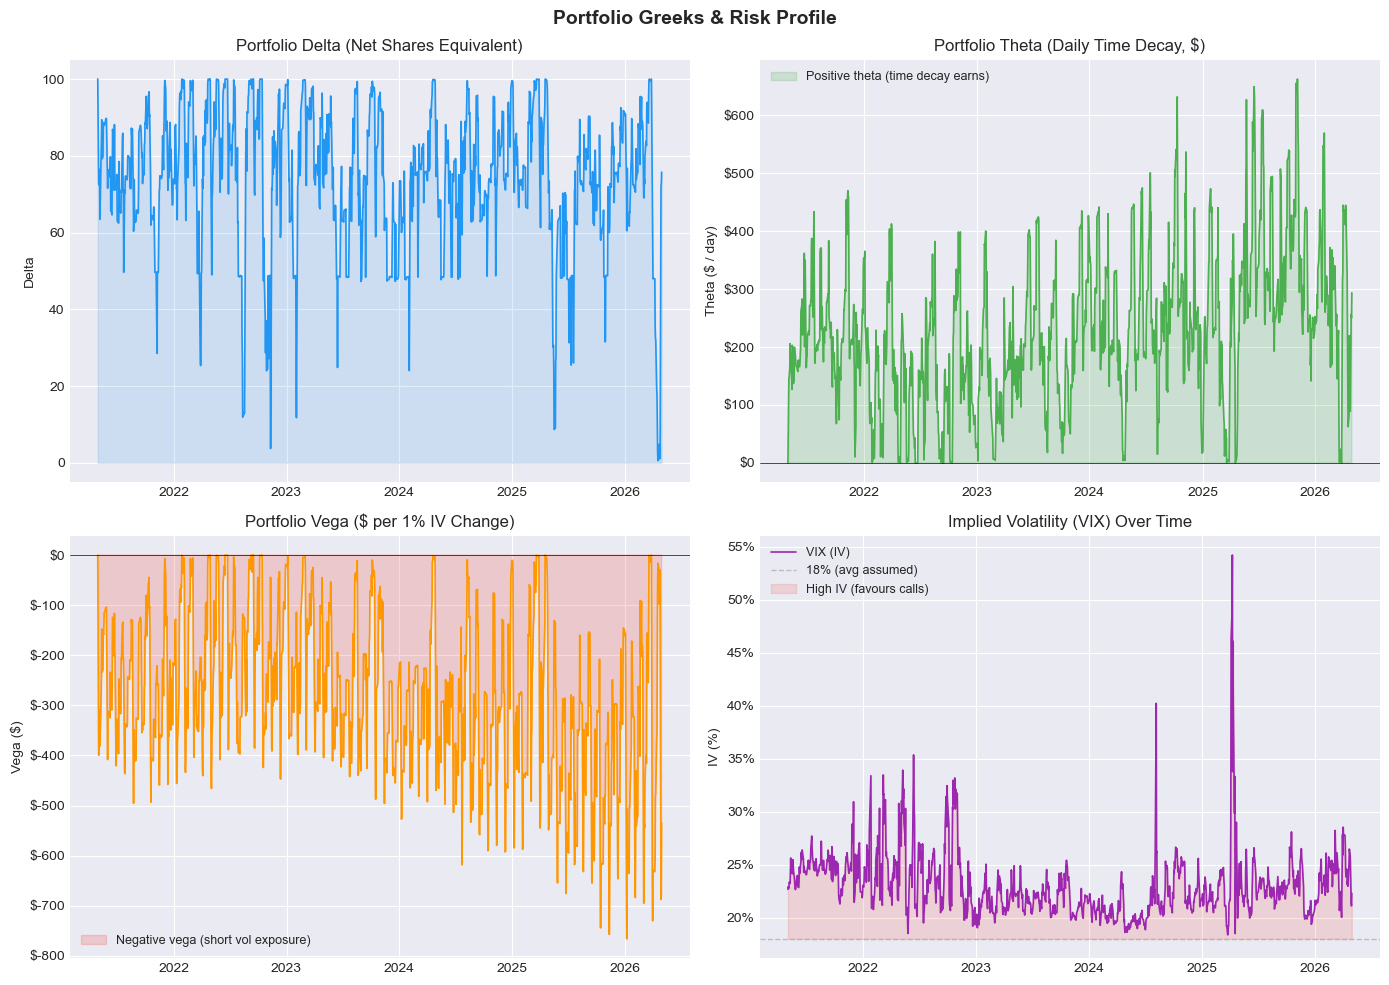

📊 Chart saved


In [145]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Portfolio Greeks & Risk Profile', fontsize=14, fontweight='bold')

# ── Delta ───────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(port_df.index, port_df['delta'], color=COLORS['primary'], lw=1.2)
ax.fill_between(port_df.index, port_df['delta'],
                alpha=0.15, color=COLORS['primary'])
ax.set_title('Portfolio Delta (Net Shares Equivalent)')
ax.set_ylabel('Delta')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Theta ───────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(port_df.index, port_df['theta'], color=COLORS['success'], lw=1.2)
ax.fill_between(port_df.index, port_df['theta'], 0,
                where=port_df['theta'] > 0, alpha=0.2, color=COLORS['success'],
                label='Positive theta (time decay earns)')
ax.fill_between(port_df.index, port_df['theta'], 0,
                where=port_df['theta'] < 0, alpha=0.2, color=COLORS['danger'])
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Portfolio Theta (Daily Time Decay, $)')
ax.set_ylabel('Theta ($ / day)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── Vega ────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(port_df.index, port_df['vega'], color=COLORS['secondary'], lw=1.2)
ax.fill_between(port_df.index, port_df['vega'], 0,
                where=port_df['vega'] < 0, alpha=0.2, color=COLORS['danger'],
                label='Negative vega (short vol exposure)')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Portfolio Vega ($ per 1% IV Change)')
ax.set_ylabel('Vega ($)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── IV (VIX) over time ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(port_df.index, port_df['iv'] * 100, color=COLORS['purple'], lw=1.2, label='VIX (IV)')
ax.axhline(18, color=COLORS['gray'], lw=1, linestyle='--', alpha=0.6, label='18% (avg assumed)')
ax.fill_between(port_df.index, port_df['iv']*100, 18,
                where=port_df['iv']*100 > 18, alpha=0.15, color=COLORS['danger'],
                label='High IV (favours calls)')
ax.set_title('Implied Volatility (VIX) Over Time')
ax.set_ylabel('IV (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

fig.tight_layout()
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / '04_greeks.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved')

## 12. Risk Metrics Deep Dive

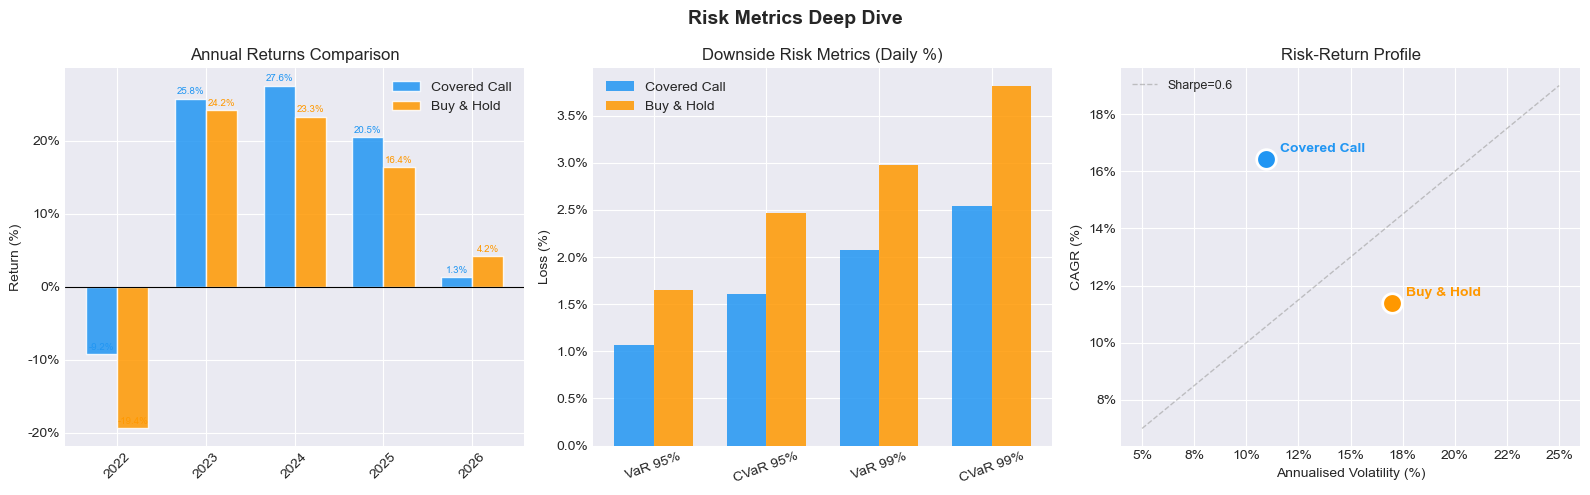

📊 Chart saved


In [146]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Risk Metrics Deep Dive', fontsize=14, fontweight='bold')

# ── Annual Returns Bar Chart ────────────────────────────────────────────────
ax = axes[0]
annual_strat = port_df['portfolio_value'].resample('YE').last().pct_change().dropna() * 100
annual_bh    = bh_df['portfolio_value'].resample('YE').last().pct_change().dropna() * 100
years_idx = annual_strat.index.year
x = np.arange(len(years_idx))
w = 0.35
bars1 = ax.bar(x - w/2, annual_strat.values, w, label='Covered Call',
               color=COLORS['primary'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, annual_bh.values, w, label='Buy & Hold',
               color=COLORS['secondary'], alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years_idx, rotation=45)
ax.set_title('Annual Returns Comparison')
ax.set_ylabel('Return (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=7, color=COLORS['primary'])
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=7, color=COLORS['secondary'])

# ── VaR / CVaR Comparison ───────────────────────────────────────────────────
ax = axes[1]
risk_labels = ['VaR 95%', 'CVaR 95%', 'VaR 99%', 'CVaR 99%']
strat_risks = [
    abs(strat_metrics['var_95'])*100,
    abs(strat_metrics['cvar_95'])*100,
    abs(strat_metrics['var_99'])*100,
    abs(strat_metrics['cvar_99'])*100,
]
bh_risks = [
    abs(bh_metrics['var_95'])*100,
    abs(bh_metrics['cvar_95'])*100,
    abs(bh_metrics['var_99'])*100,
    abs(bh_metrics['cvar_99'])*100,
]
x2 = np.arange(len(risk_labels))
ax.bar(x2 - w/2, strat_risks, w, label='Covered Call', color=COLORS['primary'], alpha=0.85)
ax.bar(x2 + w/2, bh_risks,    w, label='Buy & Hold',   color=COLORS['secondary'], alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(risk_labels, rotation=20)
ax.set_title('Downside Risk Metrics (Daily %)')
ax.set_ylabel('Loss (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend()

# ── Risk-Return Scatter ─────────────────────────────────────────────────────
ax = axes[2]
strategies = {
    'Covered Call': (strat_metrics['ann_volatility']*100, strat_metrics['cagr']*100),
    'Buy & Hold':   (bh_metrics['ann_volatility']*100,   bh_metrics['cagr']*100),
}
for name, (vol, ret) in strategies.items():
    color = COLORS['primary'] if 'Covered' in name else COLORS['secondary']
    ax.scatter(vol, ret, s=200, color=color, zorder=5, edgecolors='white', lw=2)
    ax.annotate(name, (vol, ret), textcoords='offset points', xytext=(10, 5),
                fontsize=10, color=color, fontweight='bold')

# Efficient frontier reference line
vol_range = np.linspace(5, 25, 100)
sharpe_ref = 0.6
ax.plot(vol_range, CONFIG['risk_free_rate']*100 + sharpe_ref * vol_range,
        color=COLORS['gray'], linestyle='--', lw=1, alpha=0.6, label=f'Sharpe={sharpe_ref}')
ax.set_title('Risk-Return Profile')
ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('CAGR (%)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)

fig.tight_layout()
output_dir.mkdir(parents=True, exist_ok=True)
risk_metrics_path = output_dir / '05_risk_metrics.png'
plt.savefig(risk_metrics_path, dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved')

## 13. Summary & Interpretation

In [147]:
print('\n' + '═'*65)
print('  STRATEGY SUMMARY & INTERPRETATION')
print('═'*65)

cc_r = strat_metrics['cagr']
bh_r = bh_metrics['cagr']
cc_v = strat_metrics['ann_volatility']
bh_v = bh_metrics['ann_volatility']
cc_s = strat_metrics['sharpe']
bh_s = bh_metrics['sharpe']
cc_d = abs(strat_metrics['max_drawdown'])
bh_d = abs(bh_metrics['max_drawdown'])

print(f"""
📈 RETURN:     Covered Call CAGR = {cc_r:.1%}  |  Buy & Hold CAGR = {bh_r:.1%}
   {'✅ Strategy outperformed on an absolute return basis.' if cc_r > bh_r
    else '⚠️  Buy & Hold delivered higher absolute returns — typical in strongly'}
   {'  ' if cc_r > bh_r else '   trending bull markets where the call premium caps upside.'}

📉 VOLATILITY: Covered Call = {cc_v:.1%}  |  Buy & Hold = {bh_v:.1%}
   {'✅ Strategy reduced volatility — premium income acts as a cushion.' if cc_v < bh_v
    else '⚠️  Volatility was not materially reduced.'}

⚖️  SHARPE:     Covered Call = {cc_s:.3f}  |  Buy & Hold = {bh_s:.3f}
   {'✅ Better risk-adjusted returns — more return per unit of risk.' if cc_s > bh_s
    else '⚠️  Buy & Hold had a better risk-adjusted ratio.'}

📊 DRAWDOWN:   Covered Call = {cc_d:.1%}  |  Buy & Hold = {bh_d:.1%}
   {'✅ Strategy experienced smaller peak-to-trough losses.' if cc_d < bh_d
    else '⚠️  Max drawdown was similar or larger — premium alone does not protect'}
   {'  ' if cc_d < bh_d else '   against large equity declines.'}

💰 OPTIONS:    {strat_metrics.get('n_trades', 0)} trades, 
               ${strat_metrics.get('total_premium', 0):,.0f} total premium collected,
               {strat_metrics.get('win_rate', 0):.0%} win rate,
               {strat_metrics.get('assign_rate', 0):.0%} assignment rate

📌 KEY TAKEAWAYS:
   1. Covered calls are a yield-enhancement strategy, not a hedge.
   2. They shine in sideways/mildly bullish markets but lag in strong rallies.
   3. Assignment risk means equity may be called away at the strike price.
   4. Negative vega exposure means high-IV regimes (like COVID-19 in 2020)
      work AGAINST you when opening new positions.
   5. The strategy naturally reduces portfolio beta toward 0.5–0.7.
""")
print('═'*65)


═════════════════════════════════════════════════════════════════
  STRATEGY SUMMARY & INTERPRETATION
═════════════════════════════════════════════════════════════════

📈 RETURN:     Covered Call CAGR = 16.4%  |  Buy & Hold CAGR = 11.4%
   ✅ Strategy outperformed on an absolute return basis.
     

📉 VOLATILITY: Covered Call = 11.0%  |  Buy & Hold = 17.0%
   ✅ Strategy reduced volatility — premium income acts as a cushion.

⚖️  SHARPE:     Covered Call = 1.077  |  Buy & Hold = 0.484
   ✅ Better risk-adjusted returns — more return per unit of risk.

📊 DRAWDOWN:   Covered Call = 13.6%  |  Buy & Hold = 25.4%
   ✅ Strategy experienced smaller peak-to-trough losses.
     

💰 OPTIONS:    66 trades, 
               $397,464 total premium collected,
               92% win rate,
               17% assignment rate

📌 KEY TAKEAWAYS:
   1. Covered calls are a yield-enhancement strategy, not a hedge.
   2. They shine in sideways/mildly bullish markets but lag in strong rallies.
   3. Assignment ri

---
## 14. Interactive HTML Dashboard
Generates a self-contained HTML dashboard with all charts and metrics, rendered inline in the notebook and saved as a standalone `.html` file you can open in any browser.

In [148]:
import json
from IPython.display import HTML, display as ipy_display

# ── 1. Prepare all data payloads from the backtest ──────────────────────────

def prep_dashboard_data(port_df, bh_df, trades_df, strat_metrics, bh_metrics, price_data):
    """Serialise all backtest results into JSON-friendly dicts for the dashboard."""

    # Decimate to ~500 points for chart performance
    step = max(1, len(port_df) // 500)
    idx  = port_df.index[::step]

    equity_labels = [str(d.date()) for d in idx]
    equity_cc     = [round(float(v), 2) for v in port_df['portfolio_value'][::step]]
    equity_bh     = [round(float(v), 2) for v in bh_df['portfolio_value'].reindex(port_df.index).ffill()[::step]]

    # Drawdown
    def drawdown_series(vals):
        s = pd.Series(vals)
        peak = s.cummax()
        return ((s - peak) / peak * 100).round(2).tolist()

    dd_cc = drawdown_series(equity_cc)
    dd_bh = drawdown_series(equity_bh)

    # Rolling 126-day Sharpe
    rf_d = CONFIG['risk_free_rate'] / 252
    pv_full = port_df['portfolio_value']
    bh_full = bh_df['portfolio_value'].reindex(port_df.index).ffill()

    def roll_sharpe(pv, w=126):
        r = pv.pct_change()
        mu  = r.rolling(w).mean()
        sig = r.rolling(w).std()
        s = ((mu * 252 - CONFIG['risk_free_rate']) / (sig * np.sqrt(252))).round(3)
        return [None if np.isnan(v) else float(v) for v in s[::step]]

    roll_cc = roll_sharpe(pv_full)
    roll_bh = roll_sharpe(bh_full)

    # Annual returns
    def annual_rets(pv):
        y = pv.resample('YE').last().pct_change().dropna() * 100
        return {str(yr): round(float(v), 1) for yr, v in zip(y.index.year, y.values)}

    ann_cc = annual_rets(pv_full)
    ann_bh = annual_rets(bh_full)
    year_keys = sorted(set(list(ann_cc.keys()) + list(ann_bh.keys())))

    # Return distribution
    rets_pct = pv_full.pct_change().dropna() * 100
    bins = np.linspace(-5, 5, 61)
    hist_counts, _ = np.histogram(rets_pct.clip(-5, 5), bins=bins)
    hist_labels = [round(float((bins[i] + bins[i+1]) / 2), 2) for i in range(len(bins)-1)]
    sorted_rets = np.sort(rets_pct.values)
    var95 = round(float(np.percentile(sorted_rets, 5)), 2)
    var99 = round(float(np.percentile(sorted_rets, 1)), 2)

    # VIX
    vix_vals = [round(float(v)*100, 1) if not np.isnan(v) else 18.0
                for v in price_data['vix'][::step]]

    # Delta
    delta_vals = [round(float(v), 1) for v in port_df['delta'][::step]]

    # Trades
    if len(trades_df) > 0:
        trade_pnls  = [round(float(v), 2) for v in trades_df['pnl']]
        cum_prem    = trades_df['premium_collected'].cumsum().round(2).tolist()
        cum_pnl     = trades_df['pnl'].cumsum().round(2).tolist()
        trade_dates = [str(pd.to_datetime(d).date()) for d in trades_df['close_date']]
    else:
        trade_pnls = cum_prem = cum_pnl = trade_dates = []

    # Monthly heatmap
    monthly = pv_full.resample('ME').last().pct_change().dropna() * 100
    monthly_df = pd.DataFrame({'ret': monthly, 'year': monthly.index.year, 'month': monthly.index.month})
    pivot = monthly_df.pivot_table(values='ret', index='year', columns='month').round(1)
    heatmap = {}
    for yr in pivot.index:
        heatmap[str(yr)] = [round(float(pivot.loc[yr, m]), 1) if m in pivot.columns and not np.isnan(pivot.loc[yr, m]) else None
                            for m in range(1, 13)]

    # Risk metrics
    risk_metrics = {
        'cc': {
            'total_return': round(strat_metrics['total_return']*100, 1),
            'cagr':         round(strat_metrics['cagr']*100, 1),
            'sharpe':       round(strat_metrics['sharpe'], 2),
            'sortino':      round(strat_metrics['sortino'], 2),
            'calmar':       round(strat_metrics['calmar'], 2),
            'max_dd':       round(abs(strat_metrics['max_drawdown'])*100, 1),
            'ann_vol':      round(strat_metrics['ann_volatility']*100, 1),
            'var95':        round(abs(strat_metrics['var_95'])*100, 2),
            'cvar95':       round(abs(strat_metrics['cvar_95'])*100, 2),
            'var99':        round(abs(strat_metrics['var_99'])*100, 2),
            'cvar99':       round(abs(strat_metrics['cvar_99'])*100, 2),
            'omega':        round(strat_metrics['omega_ratio'], 2),
            'hit_rate':     round(strat_metrics['hit_rate']*100, 1),
            'best_day':     round(strat_metrics['best_day']*100, 2),
            'worst_day':    round(strat_metrics['worst_day']*100, 2),
            'n_trades':     int(strat_metrics.get('n_trades', 0)),
            'win_rate':     round(strat_metrics.get('win_rate', 0)*100, 1),
            'total_premium':round(strat_metrics.get('total_premium', 0), 0),
            'avg_premium':  round(strat_metrics.get('avg_premium', 0), 2),
            'profit_factor':round(strat_metrics.get('profit_factor', 0), 2),
            'assign_rate':  round(strat_metrics.get('assign_rate', 0)*100, 1),
        },
        'bh': {
            'total_return': round(bh_metrics['total_return']*100, 1),
            'cagr':         round(bh_metrics['cagr']*100, 1),
            'sharpe':       round(bh_metrics['sharpe'], 2),
            'sortino':      round(bh_metrics['sortino'], 2),
            'calmar':       round(bh_metrics['calmar'], 2),
            'max_dd':       round(abs(bh_metrics['max_drawdown'])*100, 1),
            'ann_vol':      round(bh_metrics['ann_volatility']*100, 1),
            'var95':        round(abs(bh_metrics['var_95'])*100, 2),
            'cvar95':       round(abs(bh_metrics['cvar_95'])*100, 2),
            'var99':        round(abs(bh_metrics['var_99'])*100, 2),
            'cvar99':       round(abs(bh_metrics['cvar_99'])*100, 2),
            'omega':        round(bh_metrics['omega_ratio'], 2),
            'hit_rate':     round(bh_metrics['hit_rate']*100, 1),
            'best_day':     round(bh_metrics['best_day']*100, 2),
            'worst_day':    round(bh_metrics['worst_day']*100, 2),
        }
    }

    return {
        'equity_labels': equity_labels,
        'equity_cc': equity_cc,
        'equity_bh': equity_bh,
        'dd_cc': dd_cc,
        'dd_bh': dd_bh,
        'roll_sharpe_cc': roll_cc,
        'roll_sharpe_bh': roll_bh,
        'year_keys': year_keys,
        'ann_cc': ann_cc,
        'ann_bh': ann_bh,
        'hist_labels': hist_labels,
        'hist_counts': hist_counts.tolist(),
        'var95': var95,
        'var99': var99,
        'vix_vals': vix_vals,
        'delta_vals': delta_vals,
        'trade_pnls': trade_pnls,
        'cum_prem': cum_prem,
        'cum_pnl': cum_pnl,
        'trade_dates': trade_dates,
        'heatmap': heatmap,
        'risk_metrics': risk_metrics,
        'ticker': CONFIG['ticker'],
        'start': CONFIG['start_date'],
        'end':   CONFIG['end_date'],
        'initial_capital': CONFIG['initial_capital'],
    }

dash_data = prep_dashboard_data(port_df, bh_df, trades_df, strat_metrics, bh_metrics, price_data)
print(f'✅ Dashboard data prepared — {len(dash_data["equity_labels"])} chart points, {len(dash_data["trade_pnls"])} trades')

✅ Dashboard data prepared — 626 chart points, 66 trades


In [152]:
import base64

def build_dashboard_html(data, embed_height=2400):
    """Build a self-contained HTML dashboard from backtest data dict."""

    m   = data['risk_metrics']
    cc  = m['cc']
    bh  = m['bh']
    js  = json.dumps(data)

    outputs_dir = Path.cwd() / 'outputs'

    def encode_png(path):
        if not path.exists():
            return None
        return base64.b64encode(path.read_bytes()).decode('ascii')

    report_specs = [
        ('Equity Curve Overview', '01_equity_curve.png'),
        ('Return Distribution Analysis', '02_return_distribution.png'),
        ('Trade-Level Analysis', '03_trade_analysis.png'),
        ('Portfolio Greeks & Risk Profile', '04_greeks.png'),
        ('Risk Metrics Deep Dive', '05_risk_metrics.png'),
    ]

    report_cards = []
    for title, filename in report_specs:
        encoded = encode_png(outputs_dir / filename)
        if encoded is None:
            continue
        report_cards.append(
            f'''<div class="card report-card">\
<div class="card-title">{title}</div>\
<div class="report-image-wrap">\
<img class="report-image" src="data:image/png;base64,{encoded}" alt="{title}">\
</div>\
<div class="report-caption">Source: outputs/{filename}</div>\
</div>'''
        )

    report_gallery = '\n'.join(report_cards) if report_cards else (
        '<div class="card full"><div class="card-title">Notebook PNG Reports</div>'
        '<div class="report-caption">No saved PNG reports were found in the outputs directory.</div></div>'
    )

    html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>{data['ticker']} Covered Call Backtest Dashboard</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  :root {{
    --bg: #f8f9fb; --surface: #ffffff; --surface2: #f1f3f7;
    --border: rgba(0,0,0,0.08); --text: #1a1d23; --muted: #6b7280;
    --blue: #2563eb; --blue-light: rgba(37,99,235,0.1);
    --amber: #d97706; --amber-light: rgba(217,119,6,0.1);
    --green: #059669; --green-light: rgba(5,150,105,0.1);
    --red: #dc2626; --red-light: rgba(220,38,38,0.1);
    --purple: #7c3aed; --purple-light: rgba(124,58,237,0.1);
    --radius: 10px; --shadow: 0 1px 3px rgba(0,0,0,0.07), 0 1px 2px rgba(0,0,0,0.05);
  }}
  @media (prefers-color-scheme: dark) {{
    :root {{
      --bg: #0f1117; --surface: #1a1d27; --surface2: #252836;
      --border: rgba(255,255,255,0.08); --text: #e8eaf0; --muted: #9ca3af;
      --blue: #60a5fa; --blue-light: rgba(96,165,250,0.12);
      --amber: #fbbf24; --amber-light: rgba(251,191,36,0.12);
      --green: #34d399; --green-light: rgba(52,211,153,0.12);
      --red: #f87171; --red-light: rgba(248,113,113,0.12);
      --purple: #a78bfa; --purple-light: rgba(167,139,250,0.12);
    }}
  }}
  body {{ background: var(--bg); color: var(--text); font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; font-size: 14px; line-height: 1.5; }}
  .dash {{ max-width: 1680px; margin: 0 auto; padding: 28px 24px 40px; }}
  .header {{ display: flex; justify-content: space-between; align-items: flex-start; margin-bottom: 24px; flex-wrap: wrap; gap: 12px; }}
  .header-title {{ font-size: 24px; font-weight: 600; letter-spacing: -0.3px; }}
  .header-sub {{ font-size: 13px; color: var(--muted); margin-top: 4px; }}
  .badge {{ display: inline-flex; align-items: center; gap: 5px; font-size: 12px; font-weight: 500; padding: 4px 10px; border-radius: 20px; }}
  .badge-green {{ background: var(--green-light); color: var(--green); }}
  .section-label {{ font-size: 11px; font-weight: 600; letter-spacing: 0.07em; text-transform: uppercase; color: var(--muted); margin-bottom: 12px; }}
  .metric-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(140px, 1fr)); gap: 10px; margin-bottom: 20px; }}
  .metric {{ background: var(--surface2); border-radius: var(--radius); padding: 12px 14px; }}
  .metric-label {{ font-size: 11px; color: var(--muted); margin-bottom: 4px; }}
  .metric-value {{ font-size: 22px; font-weight: 600; line-height: 1; }}
  .metric-sub {{ font-size: 11px; color: var(--muted); margin-top: 4px; }}
  .pos {{ color: var(--green); }} .neg {{ color: var(--red); }} .neu {{ color: var(--blue); }}
  .grid2 {{ display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin-bottom: 16px; }}
  .grid3 {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px; margin-bottom: 16px; }}
  .report-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin-bottom: 16px; }}
  .full {{ grid-column: 1 / -1; }}
  .card {{ background: var(--surface); border: 1px solid var(--border); border-radius: var(--radius); box-shadow: var(--shadow); padding: 18px 20px; }}
  .card-title {{ font-size: 12px; font-weight: 600; color: var(--muted); margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.04em; }}
  .legend {{ display: flex; gap: 16px; flex-wrap: wrap; font-size: 11px; color: var(--muted); margin-bottom: 8px; }}
  .legend-dot {{ display: inline-block; width: 10px; height: 10px; border-radius: 2px; margin-right: 4px; vertical-align: middle; }}
  .chart-wrap {{ position: relative; width: 100%; }}
  .report-image-wrap {{ background: var(--surface2); border-radius: calc(var(--radius) - 2px); overflow: hidden; }}
  .report-image {{ width: 100%; height: auto; display: block; }}
  .report-caption {{ font-size: 11px; color: var(--muted); margin-top: 8px; }}
  hr.div {{ border: none; border-top: 1px solid var(--border); margin: 22px 0; }}
  .risk-row {{ display: flex; align-items: center; gap: 10px; margin-bottom: 10px; font-size: 12px; }}
  .risk-label {{ width: 68px; color: var(--muted); flex-shrink: 0; }}
  .risk-bars {{ flex: 1; display: flex; flex-direction: column; gap: 3px; }}
  .bar-row {{ display: flex; align-items: center; gap: 6px; }}
  .bar-tag {{ width: 26px; font-size: 10px; color: var(--muted); flex-shrink: 0; }}
  .bar-track {{ flex: 1; height: 5px; background: var(--surface2); border-radius: 3px; overflow: hidden; }}
  .bar-fill {{ height: 100%; border-radius: 3px; }}
  .bar-val {{ width: 40px; text-align: right; font-size: 11px; font-weight: 500; color: var(--text); }}
  .hm-table {{ width: 100%; border-collapse: separate; border-spacing: 2px; font-size: 10px; }}
  .hm-table th {{ text-align: center; color: var(--muted); font-weight: 500; padding: 2px; }}
  .hm-table td {{ text-align: center; padding: 4px 2px; border-radius: 4px; font-size: 10px; white-space: nowrap; }}
  .compare-table {{ width: 100%; border-collapse: collapse; font-size: 12px; }}
  .compare-table th {{ text-align: left; padding: 8px 10px; border-bottom: 2px solid var(--border); color: var(--muted); font-size: 11px; text-transform: uppercase; letter-spacing: 0.04em; }}
  .compare-table td {{ padding: 7px 10px; border-bottom: 1px solid var(--border); }}
  .compare-table tr:last-child td {{ border-bottom: none; }}
  .compare-table .row-label {{ color: var(--muted); }}
  .compare-table .cc-val {{ font-weight: 600; color: var(--blue); }}
  .compare-table .bh-val {{ color: var(--amber); }}
  @media (max-width: 980px) {{ .grid3, .report-grid {{ grid-template-columns: 1fr; }} }}
  @media (max-width: 700px) {{ .grid2, .grid3, .report-grid {{ grid-template-columns: 1fr; }} .metric-grid {{ grid-template-columns: repeat(2, 1fr); }} .dash {{ padding: 20px 14px 32px; }} }}
</style>
</head>
<body>
<div class="dash">

  <div class="header">
    <div>
      <div class="header-title">{data['ticker']} &mdash; Covered Call Backtest</div>
      <div class="header-sub">{data['start']} &rarr; {data['end']} &nbsp;&middot;&nbsp; Initial capital: ${data['initial_capital']:,} &nbsp;&middot;&nbsp; ~30-delta monthly calls, 30 DTE</div>
    </div>
    <span class="badge badge-green">&#x2713; Backtest complete</span>
  </div>

  <div class="section-label">Performance overview</div>
  <div class="metric-grid">
    <div class="metric"><div class="metric-label">Total return</div><div class="metric-value pos">{cc['total_return']:.1f}%</div><div class="metric-sub">vs {bh['total_return']:.1f}% B&amp;H</div></div>
    <div class="metric"><div class="metric-label">CAGR</div><div class="metric-value pos">{cc['cagr']:.1f}%</div><div class="metric-sub">vs {bh['cagr']:.1f}% B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Sharpe ratio</div><div class="metric-value neu">{cc['sharpe']:.2f}</div><div class="metric-sub">vs {bh['sharpe']:.2f} B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Sortino</div><div class="metric-value neu">{cc['sortino']:.2f}</div><div class="metric-sub">vs {bh['sortino']:.2f} B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Max drawdown</div><div class="metric-value neg">&minus;{cc['max_dd']:.1f}%</div><div class="metric-sub">vs &minus;{bh['max_dd']:.1f}% B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Ann. volatility</div><div class="metric-value">{cc['ann_vol']:.1f}%</div><div class="metric-sub">vs {bh['ann_vol']:.1f}% B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Calmar</div><div class="metric-value neu">{cc['calmar']:.2f}</div><div class="metric-sub">vs {bh['calmar']:.2f} B&amp;H</div></div>
    <div class="metric"><div class="metric-label">Option win rate</div><div class="metric-value pos">{cc['win_rate']:.1f}%</div><div class="metric-sub">{cc['n_trades']} trades</div></div>
    <div class="metric"><div class="metric-label">Total premium</div><div class="metric-value pos">${cc['total_premium']:,.0f}</div><div class="metric-sub">avg ${cc['avg_premium']:,.0f}/trade</div></div>
  </div>

  <div class="grid2">
    <div class="card full">
      <div class="card-title">Equity curve</div>
      <div class="legend">
        <span><span class="legend-dot" style="background:#2563eb;"></span>Covered call</span>
        <span><span class="legend-dot" style="background:#d97706;"></span>Buy &amp; hold ({data['ticker']})</span>
      </div>
      <div class="chart-wrap" style="height:340px;"><canvas id="c-equity"></canvas></div>
    </div>
  </div>

  <div class="grid2">
    <div class="card">
      <div class="card-title">Drawdown</div>
      <div class="legend"><span><span class="legend-dot" style="background:#2563eb;"></span>CC</span><span><span class="legend-dot" style="background:#d97706;"></span>B&amp;H</span></div>
      <div class="chart-wrap" style="height:240px;"><canvas id="c-dd"></canvas></div>
    </div>
    <div class="card">
      <div class="card-title">Rolling 6-month Sharpe</div>
      <div class="legend"><span><span class="legend-dot" style="background:#2563eb;"></span>CC</span><span><span class="legend-dot" style="background:#d97706;"></span>B&amp;H</span></div>
      <div class="chart-wrap" style="height:240px;"><canvas id="c-sharpe"></canvas></div>
    </div>
  </div>

  <div class="grid2">
    <div class="card">
      <div class="card-title">Annual returns</div>
      <div class="legend"><span><span class="legend-dot" style="background:#2563eb;"></span>CC</span><span><span class="legend-dot" style="background:#d97706;"></span>B&amp;H</span></div>
      <div class="chart-wrap" style="height:260px;"><canvas id="c-annual"></canvas></div>
    </div>
    <div class="card">
      <div class="card-title">Return distribution (daily)</div>
      <div class="legend"><span><span class="legend-dot" style="background:#2563eb;"></span>Freq.</span><span style="color:#dc2626;"><span class="legend-dot" style="background:#dc2626;"></span>VaR 95%</span><span style="color:#991b1b;"><span class="legend-dot" style="background:#991b1b;"></span>VaR 99%</span></div>
      <div class="chart-wrap" style="height:260px;"><canvas id="c-dist"></canvas></div>
    </div>
  </div>

  <hr class="div">
  <div class="section-label">Risk metrics</div>
  <div class="grid2">
    <div class="card">
      <div class="card-title">Downside risk comparison</div>
      <div id="risk-bars-wrap" style="margin-top:4px;"></div>
    </div>
    <div class="card">
      <div class="card-title">Risk-return scatter</div>
      <div class="chart-wrap" style="height:260px;"><canvas id="c-rr"></canvas></div>
    </div>
  </div>
  <div class="card" style="margin-bottom:16px;">
    <div class="card-title">Full metrics comparison</div>
    <table class="compare-table" id="compare-table"></table>
  </div>

  <hr class="div">
  <div class="section-label">Options &amp; trades</div>
  <div class="grid2">
    <div class="card">
      <div class="card-title">Cumulative premium &amp; net P&amp;L</div>
      <div class="legend"><span><span class="legend-dot" style="background:#059669;"></span>Premium</span><span><span class="legend-dot" style="background:#2563eb;"></span>Net P&amp;L</span></div>
      <div class="chart-wrap" style="height:240px;"><canvas id="c-prem"></canvas></div>
    </div>
    <div class="card">
      <div class="card-title">P&amp;L per trade</div>
      <div class="legend"><span><span class="legend-dot" style="background:#059669;"></span>Profit</span><span><span class="legend-dot" style="background:#dc2626;"></span>Loss</span></div>
      <div class="chart-wrap" style="height:240px;"><canvas id="c-trades"></canvas></div>
    </div>
  </div>

  <div class="grid3">
    <div class="card">
      <div class="card-title">Monthly returns heatmap (%)</div>
      <div id="heatmap-wrap" style="overflow-x:auto; margin-top:4px;"></div>
    </div>
    <div class="card">
      <div class="card-title">Portfolio delta</div>
      <div class="chart-wrap" style="height:220px;"><canvas id="c-delta"></canvas></div>
    </div>
    <div class="card">
      <div class="card-title">VIX / implied volatility</div>
      <div class="chart-wrap" style="height:220px;"><canvas id="c-vix"></canvas></div>
    </div>
  </div>

  <hr class="div">
  <div class="section-label">Notebook PNG Reports</div>
  <div class="report-grid">
    {report_gallery}
  </div>

  <div style="font-size:11px; color:var(--muted); text-align:center; margin-top:20px;">Generated by Python backtest notebook &middot; {data['ticker']} {data['start']} &rarr; {data['end']} &middot; Historical debiased option quotes, ~30&#916; monthly calls</div>
</div>

<script>
const D = {js};
const cc = D.risk_metrics.cc, bh = D.risk_metrics.bh;

const baseOpts = {{
  responsive: true, maintainAspectRatio: false,
  plugins: {{ legend: {{ display: false }}, tooltip: {{ mode: 'index', intersect: false }} }},
  elements: {{ point: {{ radius: 0 }}, line: {{ tension: 0.3 }} }},
  scales: {{ x: {{ ticks: {{ maxTicksLimit: 6, font: {{ size: 11 }} }}, grid: {{ color: 'rgba(128,128,128,0.1)' }} }},
             y: {{ ticks: {{ font: {{ size: 11 }} }}, grid: {{ color: 'rgba(128,128,128,0.1)' }} }} }}
}};

function mc(id, type, datasets, opts) {{
  return new Chart(document.getElementById(id), {{ type, data: {{ labels: D.equity_labels, datasets }}, options: {{ ...baseOpts, ...opts }} }});
}}

mc('c-equity', 'line', [
  {{ label:'Covered call', data: D.equity_cc, borderColor:'#2563eb', borderWidth:2, fill:{{target:'origin',above:'rgba(37,99,235,0.06)'}}, pointRadius:0 }},
  {{ label:'Buy & hold',   data: D.equity_bh, borderColor:'#d97706', borderWidth:1.5, borderDash:[5,4], fill:false, pointRadius:0 }}
], {{ scales: {{ x: {{ ticks: {{ maxTicksLimit:8, font:{{size:11}} }}, grid:{{color:'rgba(128,128,128,0.1)'}} }},
               y: {{ ticks: {{ callback: v => '$' + (v/1000).toFixed(0)+'k', font:{{size:11}} }}, grid:{{color:'rgba(128,128,128,0.1)'}} }} }} }});

mc('c-dd','line',[
  {{ label:'CC', data:D.dd_cc, borderColor:'#2563eb', borderWidth:1.5, fill:{{target:'origin',below:'rgba(37,99,235,0.12)'}}, pointRadius:0 }},
  {{ label:'BH', data:D.dd_bh, borderColor:'#d97706', borderWidth:1.5, borderDash:[4,3], fill:false, pointRadius:0 }}
],{{ scales:{{ x:{{ticks:{{maxTicksLimit:6,font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
              y:{{ticks:{{callback:v=>v.toFixed(0)+'%',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}}}} }});

mc('c-sharpe','line',[
  {{ label:'CC', data:D.roll_sharpe_cc, borderColor:'#2563eb', borderWidth:1.5, fill:{{target:{{value:0}},above:'rgba(5,150,105,0.1)',below:'rgba(220,38,38,0.1)'}}, pointRadius:0 }},
  {{ label:'BH', data:D.roll_sharpe_bh, borderColor:'#d97706', borderWidth:1.5, borderDash:[4,3], fill:false, pointRadius:0 }}
],{{}});

new Chart(document.getElementById('c-annual'), {{
  type: 'bar',
  data: {{
    labels: D.year_keys,
    datasets: [
      {{ label:'CC', data: D.year_keys.map(y=>D.ann_cc[y]??0), backgroundColor: D.year_keys.map(y=>(D.ann_cc[y]??0)>=0?'rgba(37,99,235,0.8)':'rgba(220,38,38,0.7)'), barPercentage:0.42 }},
      {{ label:'BH', data: D.year_keys.map(y=>D.ann_bh[y]??0), backgroundColor: D.year_keys.map(y=>(D.ann_bh[y]??0)>=0?'rgba(217,119,6,0.75)':'rgba(217,119,6,0.4)'),  barPercentage:0.42 }}
    ]
  }},
  options: {{ ...baseOpts, scales: {{ x:{{ticks:{{font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
    y:{{ticks:{{callback:v=>v+'%',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }} }}
}});

new Chart(document.getElementById('c-dist'), {{
  type:'bar',
  data:{{ labels:D.hist_labels, datasets:[{{ label:'Frequency', data:D.hist_counts, backgroundColor:'rgba(37,99,235,0.55)', borderColor:'rgba(37,99,235,0.8)', borderWidth:0.5, barPercentage:1.0, categoryPercentage:1.0 }}] }},
  options:{{ ...baseOpts,
    scales:{{ x:{{ticks:{{maxTicksLimit:9, callback:(v,i)=>D.hist_labels[i]!=null?D.hist_labels[i].toFixed(1)+'%':'',font:{{size:10}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
              y:{{ticks:{{font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }},
    plugins:{{ ...baseOpts.plugins,
      annotation: {{ annotations: {{
        var95: {{ type:'line', xMin:D.var95, xMax:D.var95, borderColor:'#dc2626', borderWidth:2, borderDash:[4,3] }},
        var99: {{ type:'line', xMin:D.var99, xMax:D.var99, borderColor:'#991b1b', borderWidth:2, borderDash:[4,3] }}
      }} }}
    }}
  }}
}});

const riskItems = [
  {{label:'VaR 95%',  cc: cc.var95,  bh: bh.var95 }},
  {{label:'CVaR 95%', cc: cc.cvar95, bh: bh.cvar95}},
  {{label:'VaR 99%',  cc: cc.var99,  bh: bh.var99 }},
  {{label:'CVaR 99%', cc: cc.cvar99, bh: bh.cvar99}},
];
const maxR = Math.max(...riskItems.map(r=>r.bh)) * 1.1;
const rbWrap = document.getElementById('risk-bars-wrap');
riskItems.forEach(r => {{
  rbWrap.innerHTML += `<div class="risk-row">
    <div class="risk-label">${{r.label}}</div>
    <div class="risk-bars">
      <div class="bar-row"><div class="bar-tag">CC</div><div class="bar-track"><div class="bar-fill" style="width:${{(r.cc/maxR*100).toFixed(1)}}%;background:#2563eb;"></div></div><div class="bar-val">${{r.cc.toFixed(2)}}%</div></div>
      <div class="bar-row"><div class="bar-tag">B&H</div><div class="bar-track"><div class="bar-fill" style="width:${{(r.bh/maxR*100).toFixed(1)}}%;background:#d97706;"></div></div><div class="bar-val">${{r.bh.toFixed(2)}}%</div></div>
    </div></div>`;
}});

new Chart(document.getElementById('c-rr'), {{
  type:'scatter',
  data: {{ datasets: [
    {{ label:'Covered call', data:[{{x:cc.ann_vol,y:cc.cagr}}], backgroundColor:'#2563eb', pointRadius:12, pointHoverRadius:14 }},
    {{ label:'Buy & hold',   data:[{{x:bh.ann_vol,y:bh.cagr}}], backgroundColor:'#d97706', pointRadius:12, pointHoverRadius:14 }},
  ]}},
  options:{{ ...baseOpts,
    plugins:{{ legend:{{display:true,labels:{{font:{{size:11}},boxWidth:10,usePointStyle:true}}}}, tooltip:{{mode:'nearest',intersect:true}} }},
    scales:{{ x:{{min:cc.ann_vol*0.7,max:bh.ann_vol*1.15, title:{{display:true,text:'Ann. Volatility (%)',font:{{size:11}}}},ticks:{{callback:v=>v+'%',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
              y:{{min:Math.min(cc.cagr,bh.cagr)*0.7,max:bh.cagr*1.15, title:{{display:true,text:'CAGR (%)',font:{{size:11}}}},ticks:{{callback:v=>v+'%',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }}
  }}
}});

const compareRows = [
  ['Total Return (%)', cc.total_return+'%', bh.total_return+'%'],
  ['CAGR (%)', cc.cagr+'%', bh.cagr+'%'],
  ['Ann. Volatility (%)', cc.ann_vol+'%', bh.ann_vol+'%'],
  ['Sharpe Ratio', cc.sharpe, bh.sharpe],
  ['Sortino Ratio', cc.sortino, bh.sortino],
  ['Calmar Ratio', cc.calmar, bh.calmar],
  ['Max Drawdown', '-'+cc.max_dd+'%', '-'+bh.max_dd+'%'],
  ['VaR 95% (daily)', cc.var95+'%', bh.var95+'%'],
  ['CVaR 95% (daily)', cc.cvar95+'%', bh.cvar95+'%'],
  ['VaR 99% (daily)', cc.var99+'%', bh.var99+'%'],
  ['CVaR 99% (daily)', cc.cvar99+'%', bh.cvar99+'%'],
  ['Omega Ratio', cc.omega, bh.omega],
  ['Daily Hit Rate', cc.hit_rate+'%', bh.hit_rate+'%'],
  ['Best Day', cc.best_day+'%', bh.best_day+'%'],
  ['Worst Day', cc.worst_day+'%', bh.worst_day+'%'],
  ['# Option Trades', cc.n_trades, '—'],
  ['Option Win Rate', cc.win_rate+'%', '—'],
  ['Profit Factor', cc.profit_factor, '—'],
  ['Assignment Rate', cc.assign_rate+'%', '—'],
];
const ct = document.getElementById('compare-table');
ct.innerHTML = '<thead><tr><th>Metric</th><th style="color:#2563eb;">Covered Call</th><th style="color:#d97706;">Buy &amp; Hold</th></tr></thead>';
const tbody = document.createElement('tbody');
compareRows.forEach(([label, ccVal, bhVal]) => {{
  const tr = document.createElement('tr');
  tr.innerHTML = `<td class="row-label">${{label}}</td><td class="cc-val">${{ccVal}}</td><td class="bh-val">${{bhVal}}</td>`;
  tbody.appendChild(tr);
}});
ct.appendChild(tbody);

if (D.cum_prem.length > 0) {{
  new Chart(document.getElementById('c-prem'), {{
    type:'line',
    data:{{ labels:D.trade_dates, datasets:[
      {{ label:'Cumulative premium', data:D.cum_prem, borderColor:'#059669', borderWidth:2, fill:{{target:'origin',above:'rgba(5,150,105,0.08)'}}, pointRadius:0 }},
      {{ label:'Net P&L', data:D.cum_pnl, borderColor:'#2563eb', borderWidth:2, borderDash:[5,3], fill:false, pointRadius:0 }}
    ]}},
    options:{{ ...baseOpts, scales:{{ x:{{ticks:{{maxTicksLimit:6,font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
      y:{{ticks:{{callback:v=>'$'+(v/1000).toFixed(0)+'k',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }} }}
  }});
  new Chart(document.getElementById('c-trades'), {{
    type:'bar',
    data:{{ labels:D.trade_dates, datasets:[{{ label:'P&L', data:D.trade_pnls,
      backgroundColor:D.trade_pnls.map(v=>v>=0?'rgba(5,150,105,0.8)':'rgba(220,38,38,0.8)'), barPercentage:0.9 }}] }},
    options:{{ ...baseOpts, scales:{{ x:{{ticks:{{maxTicksLimit:10,font:{{size:10}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
      y:{{ticks:{{callback:v=>'$'+Math.round(v),font:{{size:10}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }} }}
  }});
}}

const months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'];
const hmWrap = document.getElementById('heatmap-wrap');
let ht = '<table class="hm-table"><thead><tr><th></th>' + months.map(m=>`<th>${{m}}</th>`).join('') + '</tr></thead><tbody>';
Object.entries(D.heatmap).forEach(([yr, vals]) => {{
  ht += `<tr><td style="padding:2px 6px;color:var(--muted);font-weight:600;font-size:10px;white-space:nowrap;">${{yr}}</td>`;
  vals.forEach(v => {{
    if (v === null) {{ ht += '<td style="background:transparent;">—</td>'; return; }}
    const intensity = Math.min(Math.abs(v) / 7, 1);
    const bg = v >= 0
      ? `rgba(5,150,105,${{(0.12 + intensity * 0.6).toFixed(2)}})`
      : `rgba(220,38,38,${{(0.12 + intensity * 0.6).toFixed(2)}})`;
    const col = v >= 0 ? '#065f46' : '#991b1b';
    ht += `<td style="background:${{bg}};color:${{col}};">${{v>0?'+':''}}${{v.toFixed(1)}}</td>`;
  }});
  ht += '</tr>';
}});
ht += '</tbody></table>';
hmWrap.innerHTML = ht;

new Chart(document.getElementById('c-delta'), {{
  type:'line',
  data:{{ labels:D.equity_labels, datasets:[{{ label:'Net delta', data:D.delta_vals, borderColor:'#7c3aed', borderWidth:1.5, fill:{{target:'origin',above:'rgba(124,58,237,0.08)'}}, pointRadius:0 }}] }},
  options:{{ ...baseOpts, scales:{{ x:{{ticks:{{maxTicksLimit:6,font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
    y:{{ticks:{{font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }} }}
}});

new Chart(document.getElementById('c-vix'), {{
  type:'line',
  data:{{ labels:D.equity_labels, datasets:[
    {{ label:'VIX', data:D.vix_vals, borderColor:'#dc2626', borderWidth:1.5, fill:{{target:{{value:20}},above:'rgba(220,38,38,0.1)',below:'rgba(37,99,235,0.06)'}}, pointRadius:0 }},
    {{ label:'20%', data:new Array(D.equity_labels.length).fill(20), borderColor:'rgba(128,128,128,0.4)', borderWidth:1, borderDash:[4,3], fill:false, pointRadius:0 }}
  ]}},
  options:{{ ...baseOpts, scales:{{ x:{{ticks:{{maxTicksLimit:6,font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}},
    y:{{ticks:{{callback:v=>v+'%',font:{{size:11}}}},grid:{{color:'rgba(128,128,128,0.1)'}}}} }} }}
}});

</script>
</body></html>
"""
    return html


dashboard_html = build_dashboard_html(dash_data)
print(f'✅ Dashboard HTML built ({len(dashboard_html):,} chars)')

✅ Dashboard HTML built (2,144,456 chars)


In [153]:
import webbrowser

# ── Save standalone HTML file ────────────────────────────────────────────────
output_path = f"{CONFIG['ticker']}_covered_call_dashboard.html"
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(dashboard_html)
print(f'💾 Dashboard saved → {output_path}')

webbrowser.open(Path(output_path).resolve().as_uri())





💾 Dashboard saved → ^GSPC_covered_call_dashboard.html


True

---
## Appendix: Raw Trades Log

In [151]:
if len(trades_df) > 0:
    display_cols = ['entry_date', 'close_date', 'S_at_entry', 'strike',
                    'entry_price', 'close_price', 'premium_collected', 'pnl', 'assigned']
    df_display = trades_df[display_cols].copy()
    df_display['entry_date']  = pd.to_datetime(df_display['entry_date']).dt.date
    df_display['close_date']  = pd.to_datetime(df_display['close_date']).dt.date
    df_display = df_display.rename(columns={
        'S_at_entry': 'SPY_entry', 'entry_price': 'call_entry',
        'close_price': 'call_close', 'premium_collected': 'premium',
    })
    for col in ['SPY_entry', 'strike', 'call_entry', 'call_close']:
        df_display[col] = df_display[col].map('{:.2f}'.format)
    for col in ['premium', 'pnl']:
        df_display[col] = df_display[col].map('${:,.2f}'.format)
    display(df_display)

,entry_date,close_date,SPY_entry,strike,call_entry,call_close,premium,pnl,assigned
0,2021-05-03,2021-05-28,4191.98,4352.00,44.18,0.00,"$4,418.00","$4,418.00",False
1,2021-06-01,2021-06-25,4216.52,4376.00,49.13,0.00,"$4,913.00","$4,913.00",False
2,2021-06-28,2021-07-23,4284.90,4455.00,51.63,0.00,"$5,163.00","$5,163.00",False
3,2021-07-26,2021-08-20,4409.58,4592.00,54.43,0.00,"$5,443.00","$5,443.00",False
4,2021-08-23,2021-09-17,4450.29,4623.00,55.29,0.00,"$5,529.00","$5,529.00",False
...,...,...,...,...,...,...,...,...,...
61,2026-01-05,2026-01-30,6892.19,7138.00,69.58,0.00,"$6,958.00","$6,958.00",False
62,2026-02-02,2026-02-27,6916.64,7222.00,75.40,0.00,"$7,540.00","$7,540.00",False
63,2026-03-02,2026-03-27,6824.36,7160.00,94.29,0.00,"$9,429.00","$9,429.00",False
64,2026-03-30,2026-04-24,6403.37,6629.00,104.96,536.08,"$10,496.00","$-43,112.01",True
